# Prediksi Ketinggian Muka Air (Tinggi Muka Air - TMA) Menggunakan Gradient Boosting
## Water Level Prediction (TMA) using Gradient Boosting — Versi Disederhanakan

Notebook ini mengimplementasikan pipeline machine learning untuk memprediksi Tinggi Muka Air (TMA) pada berbagai pos pemantauan, disusun mengikuti alur baku: **EDA → Preprocessing → Modeling & Validation → Error Analysis → Submission**.

**Kompetisi:** *Sebelas Maret Statistics Data Science 2026*
**Metrik Kompetisi:** RMSE (Root Mean Squared Error).

### Perubahan pada versi ini (dibanding notebook sebelumnya):
1. **Validasi rekursif walk-forward dihapus sementara dari tahap perbandingan model** (bagian 4). Validasi ini secara metodologis paling representatif terhadap kondisi leaderboard, tetapi menjalankannya berulang kali memakan waktu sangat lama karena harus melakukan iterasi baris-per-waktu secara sekuensial. Sebagai gantinya, perbandingan model dilakukan dengan **RMSE one-step (teacher forcing)** pada validation set kronologis — cukup representatif untuk *menyeleksi* model terbaik meski cenderung sedikit optimis dibanding kondisi leaderboard.
2. **Prediksi rekursif tetap dipertahankan, namun hanya dijalankan SATU KALI** di tahap submission (bagian 6), untuk model tunggal terbaik hasil seleksi one-step. Ini tetap diperlukan karena `test.csv` tidak menyediakan lag TMA aktual, jadi prediksi multi-step ke depan tetap harus dilakukan secara rekursif; yang dihapus hanyalah pengulangannya untuk *benchmarking*.
3. **Perbandingan model disederhanakan** menjadi baseline historis, bagging (`RandomForestRegressor`), dan boosting (LightGBM, XGBoost, CatBoost). Model klasik lain serta ensemble stacking/voting dihapus dari notebook ini.
4. **Perbaikan feature engineering** berdasarkan riset domain: encoding siklikal (`sin`/`cos`) untuk `wind_direction_deg` dan `mjo_phase` yang sebelumnya diproses sebagai numerik biasa padahal keduanya bersifat sirkuler; serta pengecekan multikolinearitas (VIF) pada `surface_pressure_hpa` vs `pressure_msl_hpa`.
5. **EDA tambahan** untuk menguji dua hipotesis dari riset domain: efek ambang kejenuhan tanah (soil-moisture threshold) dan dampak fase MJO terhadap curah hujan ekstrem.
6. **Feature importance Random Forest ditambahkan** agar interpretasi model bagging tetap tersedia setelah model klasik lain dihapus.

### Komponen Utama:
1. **EDA**: karakteristik pencilan, data hilang, pola musiman, autokorelasi, dan uji hipotesis domain (kejenuhan tanah, fase MJO).
2. **Preprocessing & Feature Engineering**: pembersihan data, fitur lag, statistik bergulir, indeks hidrologi fisik (API), fitur spasial & jaringan sungai (HydroRIVERS), encoding siklikal yang diperbaiki.
3. **Modeling & Validation**: baseline, bagging (Random Forest), dan boosting (LightGBM/XGBoost/CatBoost) dibandingkan dengan RMSE one-step.
4. **Error Analysis**: evaluasi residual, analisis sampel bererror tinggi, feature importance.
5. **Submission**: pelatihan ulang model terbaik dan prediksi rekursif tunggal untuk file submission.


## 0. Setup & Konfigurasi

In [1]:
import os
import math
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import lightgbm as lgb
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Abaikan pesan peringatan untuk output yang lebih bersih
warnings.filterwarnings('ignore')

# Konfigurasi estetika plot
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')

# Konfigurasi reproducibility global (mengikuti template)
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print("Setup Selesai. Pustaka berhasil dimuat.")


Setup Selesai. Pustaka berhasil dimuat.


## 1. Load Data

### 1.1 Impor Dataset

In [2]:
BASE = 'sebelas-maret-statistics-data-science-2026'

train_df = pd.read_csv(f'{BASE}/train.csv')
test_df = pd.read_csv(f'{BASE}/test.csv')
env_df = pd.read_csv(f'{BASE}/data_pendukung/data_lingkungan.csv')
koordinat_df = pd.read_csv(f'{BASE}/data_pendukung/koordinat_pos.csv')

# Gabungkan koordinat stasiun dengan data lingkungan
env_df = pd.merge(env_df, koordinat_df, on='nama_pos', how='left')

# === PERBAIKAN 1: Bersihkan sentinel -999 sebelum agregasi ===
numeric_cols = env_df.select_dtypes(include='number').columns
for col in numeric_cols:
    n_sentinel = (env_df[col] == -999).sum()
    if n_sentinel > 0:
        print(f'{col}: {n_sentinel} baris sentinel -999 -> diubah jadi NaN')
        env_df[col] = env_df[col].replace(-999, np.nan)

# Ubah kolom datetime menjadi objek pandas datetime
train_df['datetime'] = pd.to_datetime(train_df['datetime'])
env_df['datetime'] = pd.to_datetime(env_df['datetime'])

# Pisahkan ID pengujian untuk mendapatkan datetime dan ID stasiun
id_split = test_df['id'].str.split(' - ', n=1, expand=True)
test_df['datetime'] = pd.to_datetime(id_split[0])
test_df['nama_pos'] = id_split[1]

# Ambil daftar stasiun unik yang terurut secara alfabetis
daftar_pos = sorted(train_df['nama_pos'].unique())

solar_radiation_mj_m2: 100080 baris sentinel -999 -> diubah jadi NaN


In [3]:
train_df.head()

,datetime,nama_pos,tma_mdpl
0,2023-01-01 06:00:00,Arjowinangun - Pacitan,1.30
1,2023-01-01 12:00:00,Arjowinangun - Pacitan,1.20
2,2023-01-01 18:00:00,Arjowinangun - Pacitan,1.50
3,2023-01-02 06:00:00,Arjowinangun - Pacitan,1.45
4,2023-01-02 12:00:00,Arjowinangun - Pacitan,1.25


In [4]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 84396 entries, 0 to 84395
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   datetime  84396 non-null  datetime64[us]
 1   nama_pos  84396 non-null  str           
 2   tma_mdpl  84396 non-null  float64       
dtypes: datetime64[us](1), float64(1), str(1)
memory usage: 1.9 MB


In [5]:
# TARGET_COL & ID_COL mengikuti konvensi template â€” disesuaikan dengan dataset kompetisi ini
TARGET_COL = 'tma_mdpl'   # nama kolom target (Tinggi Muka Air)
ID_COL     = 'id'         # nama kolom identifier untuk submission


---
## 2. Exploratory Data Analysis (EDA)

> Setiap visualisasi diiringi pertanyaan dan analisis singkat, sesuai standar template.

### 2.1 Deteksi Pencilan (Outlier Detection)

**Justifikasi & Tujuan (Justification & Objective):**
Meningkatkan kualitas data dengan mendeteksi dan menangani pencilan pada target (`tma_mdpl`). Pencilan atas (banjir) sangat penting bagi model, sedangkan pencilan bawah (anomali sensor) dapat dihilangkan dengan IQR capping untuk menjaga stabilitas latih.

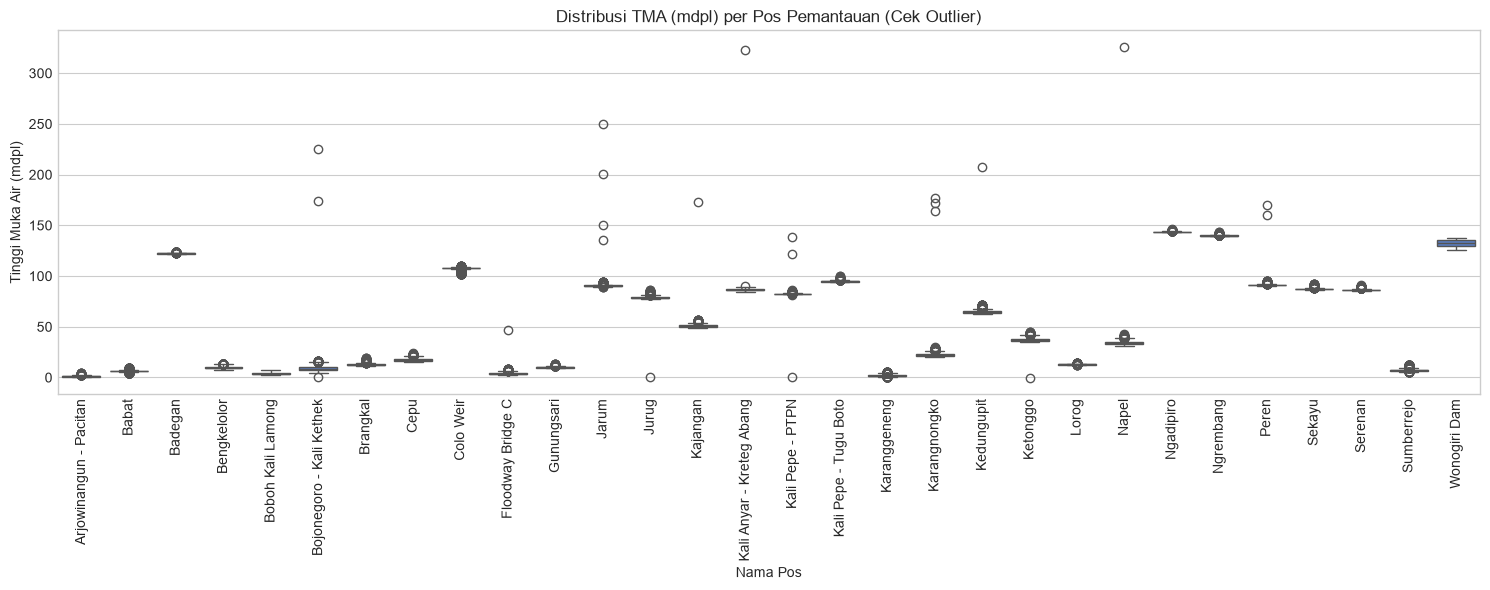

In [6]:
plt.figure(figsize=(15, 6))
sns.boxplot(data=train_df, x='nama_pos', y='tma_mdpl')
plt.xticks(rotation=90)
plt.title('Distribusi TMA (mdpl) per Pos Pemantauan (Cek Outlier)')
plt.ylabel('Tinggi Muka Air (mdpl)')
plt.xlabel('Nama Pos')
plt.tight_layout()
plt.show()

#### Insight Pencilan (Outlier Insight):
- **Observasi (Observation)**: Boxplot menunjukkan adanya pencilan bawah (lower outliers) yang cukup signifikan pada beberapa pos pemantauan (seperti Pacitan/Arjowinangun), sementara nilai atas menunjukkan distribusi yang memanjang ke atas (puncak banjir).
- **Tindakan (Action)**: Batas bawah akan dibatasi menggunakan formula `Q1 - 3.0 * IQR` untuk menyaring derau (noise) sensor, sedangkan nilai atas dibiarkan utuh.

### 2.2 Analisis Pola Deret Waktu (Time-Series Trend Analysis)

**Justifikasi & Tujuan (Justification & Objective):**
Mengidentifikasi komponen deret waktu seperti tren dan musiman, yang akan mendasari perancangan jendela statistik bergulir (rolling windows) dan lag autoregresif.

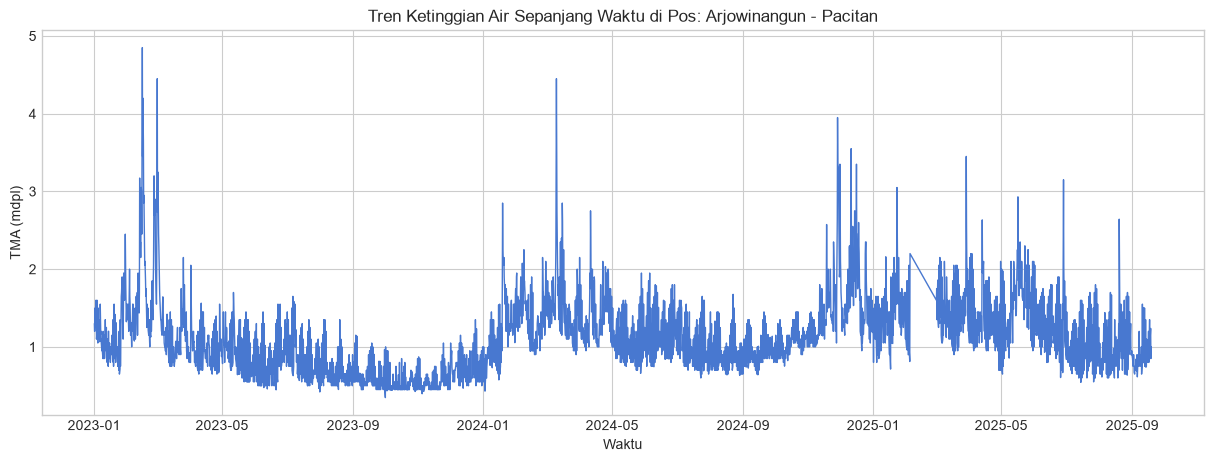

In [7]:
contoh_pos = train_df['nama_pos'].unique()[0]
data_contoh = train_df[train_df['nama_pos'] == contoh_pos]

plt.figure(figsize=(15, 5))
sns.lineplot(data=data_contoh, x='datetime', y='tma_mdpl', linewidth=1)
plt.title(f'Tren Ketinggian Air Sepanjang Waktu di Pos: {contoh_pos}')
plt.ylabel('TMA (mdpl)')
plt.xlabel('Waktu')
plt.show()

#### Insight Deret Waktu (Time-Series Insight):
- **Observasi (Observation)**: Ketinggian muka air menunjukkan pola musiman yang kuat (musim hujan vs musim kemarau) disertai fluktuasi jangka pendek yang cepat saat terjadi hujan.
- **Keputusan Pemodelan (Modeling Decision)**: Fitur lag autoregresif dan rata-rata historis sangat penting untuk memodelkan siklus musiman ini.

### 2.3 Analisis Data Hilang (Missing Value Analysis)

**Justifikasi & Tujuan (Justification & Objective):**
Mengidentifikasi letak dan volume data kosong pada data lingkungan untuk merancang strategi interpolasi tanpa kebocoran data.

In [8]:
missing_env = env_df.isnull().sum() / len(env_df) * 100
missing_env = missing_env[missing_env > 0].sort_values(ascending=False)

print("Persentase Data Hilang (Missing Values) pada Fitur Cuaca:")
print(missing_env)

Persentase Data Hilang (Missing Values) pada Fitur Cuaca:
solar_radiation_mj_m2      11.264182
nino_34                     1.458671
soil_moisture_0_7cm         0.081037
soil_moisture_28_100cm      0.081037
soil_moisture_7_28cm        0.081037
soil_moisture_100_255cm     0.081037
surface_pressure_hpa        0.081037
rmm1                        0.081037
pressure_msl_hpa            0.081037
rmm2                        0.081037
mjo_phase                   0.081037
mjo_amplitude               0.081037
mjo_active                  0.081037
dtype: float64


#### Insight Data Hilang (Missing Value Insight):
- **Observasi (Observation)**: Beberapa fitur lingkungan seperti kelembapan tanah (soil moisture) dan MJO memiliki persentase data hilang yang kecil.
- **Keputusan Pemodelan (Modeling Decision)**: Imputasi dilakukan per pos menggunakan interpolasi linier dengan batas tertentu untuk mencegah interpolasi garis lurus pada kekosongan panjang, diikuti oleh forward/backward fill.

### 2.4 Distribusi Variabel Target (TMA Distribution)

**Justifikasi & Tujuan (Justification & Objective):**
Memahami rentang dan bentuk sebaran data target TMA global sebelum digunakan untuk regresi.

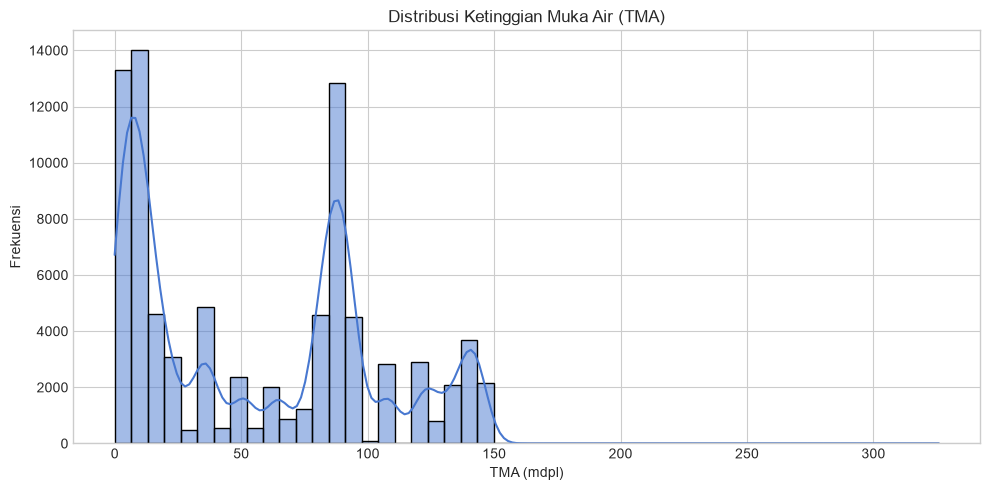

count    84396.000000
mean        56.482537
std         46.765914
min         -0.059668
25%         10.100000
50%         50.370000
75%         90.660938
max        325.830000
Name: tma_mdpl, dtype: float64


In [9]:
plt.figure(figsize=(10, 5))
sns.histplot(train_df['tma_mdpl'], kde=True, bins=50)
plt.title('Distribusi Ketinggian Muka Air (TMA)')
plt.xlabel('TMA (mdpl)')
plt.ylabel('Frekuensi')
plt.tight_layout()
plt.show()

print(train_df['tma_mdpl'].describe())

### 2.5 Perbandingan Frekuensi Sampling (Sampling Frequency Comparison)

**Justifikasi & Tujuan (Justification & Objective):**
Membandingkan resolusi temporal data TMA (misal 3 kali sehari) dengan data lingkungan (tiap jam) untuk penyelarasan timestamp yang tepat saat feature engineering.

In [10]:
print("Frekuensi sampling train_df (median selisih waktu per pos):")
sampling_train = train_df.sort_values(['nama_pos', 'datetime']).groupby('nama_pos')['datetime'].diff().median()
print(sampling_train)

print("\nFrekuensi sampling env_df (median selisih waktu per pos):")
sampling_env = env_df.sort_values(['nama_pos', 'datetime']).groupby('nama_pos')['datetime'].diff().median()
print(sampling_env)

Frekuensi sampling train_df (median selisih waktu per pos):
0 days 06:00:00

Frekuensi sampling env_df (median selisih waktu per pos):
0 days 01:00:00


### 2.6 Korelasi Fitur terhadap TMA (Feature Correlation with TMA)

**Justifikasi & Tujuan (Justification & Objective):**
Mengukur hubungan linier antara fitur lingkungan dengan target TMA untuk memandu rekayasa fitur interaksi.

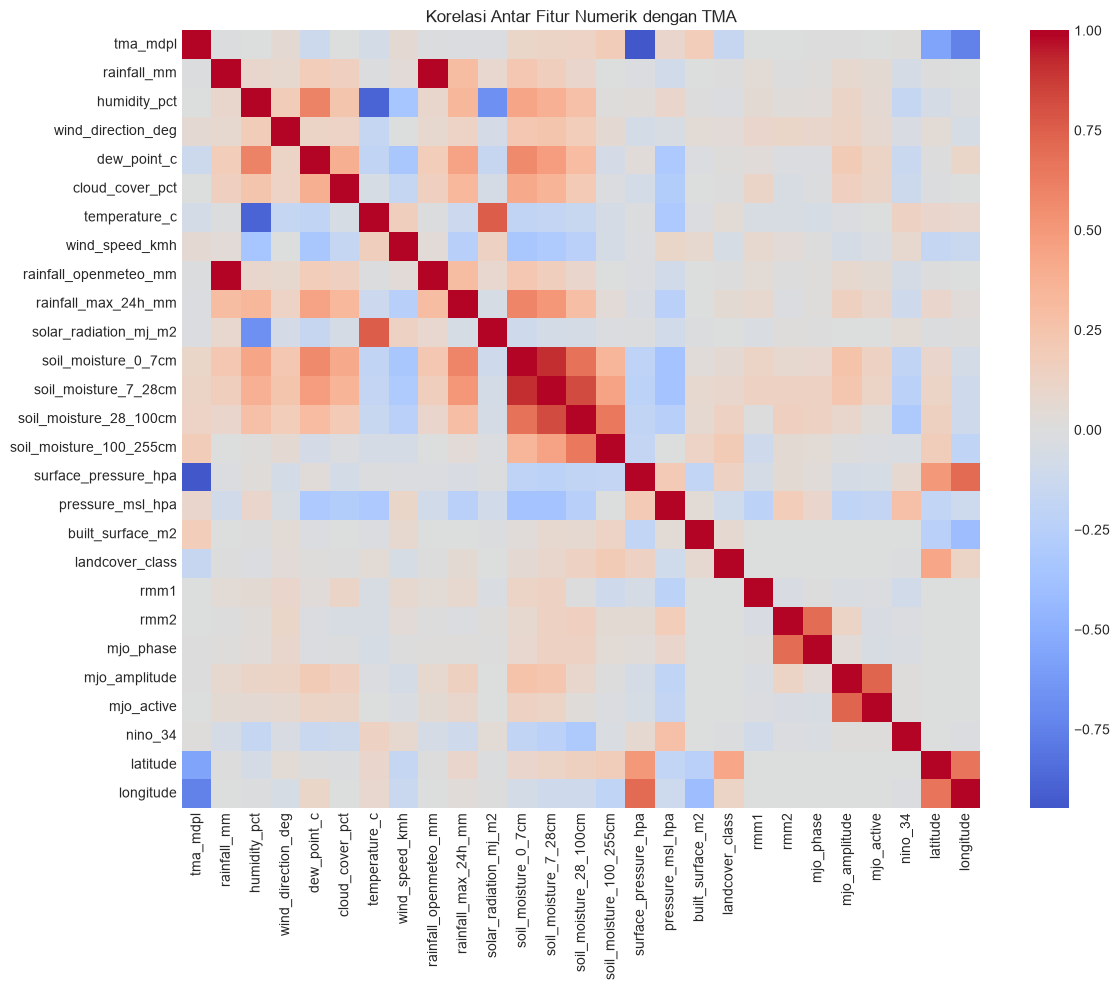

Korelasi setiap fitur terhadap TMA (diurutkan):
tma_mdpl                   1.000000
soil_moisture_100_255cm    0.189417
built_surface_m2           0.179301
soil_moisture_28_100cm     0.126973
soil_moisture_7_28cm       0.123752
soil_moisture_0_7cm        0.105786
pressure_msl_hpa           0.097006
wind_direction_deg         0.063566
wind_speed_kmh             0.057337
nino_34                    0.017774
mjo_amplitude              0.004439
mjo_phase                  0.003894
rmm2                       0.002720
mjo_active                 0.000827
humidity_pct               0.000426
cloud_cover_pct            0.000275
rmm1                      -0.002537
rainfall_openmeteo_mm     -0.005299
rainfall_mm               -0.005299
solar_radiation_mj_m2     -0.013010
rainfall_max_24h_mm       -0.025054
temperature_c             -0.076961
dew_point_c               -0.121663
landcover_class           -0.157293
latitude                  -0.565027
longitude                 -0.747092
surface_pressure

In [11]:
eda_merged = pd.merge(train_df, env_df, on=['nama_pos', 'datetime'], how='inner')

numeric_cols = eda_merged.select_dtypes(include=[np.number]).columns.tolist()

plt.figure(figsize=(12, 10))
corr = eda_merged[numeric_cols].corr()
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
plt.title('Korelasi Antar Fitur Numerik dengan TMA')
plt.tight_layout()
plt.show()

print("Korelasi setiap fitur terhadap TMA (diurutkan):")
print(corr['tma_mdpl'].sort_values(ascending=False))

### 2.7 Autokorelasi (ACF) & Autokorelasi Parsial (PACF)

**Justifikasi & Tujuan (Justification & Objective):**
Menghitung ketergantungan deret waktu terhadap masa lalunya untuk menentukan jumlah lag minimum yang optimal.

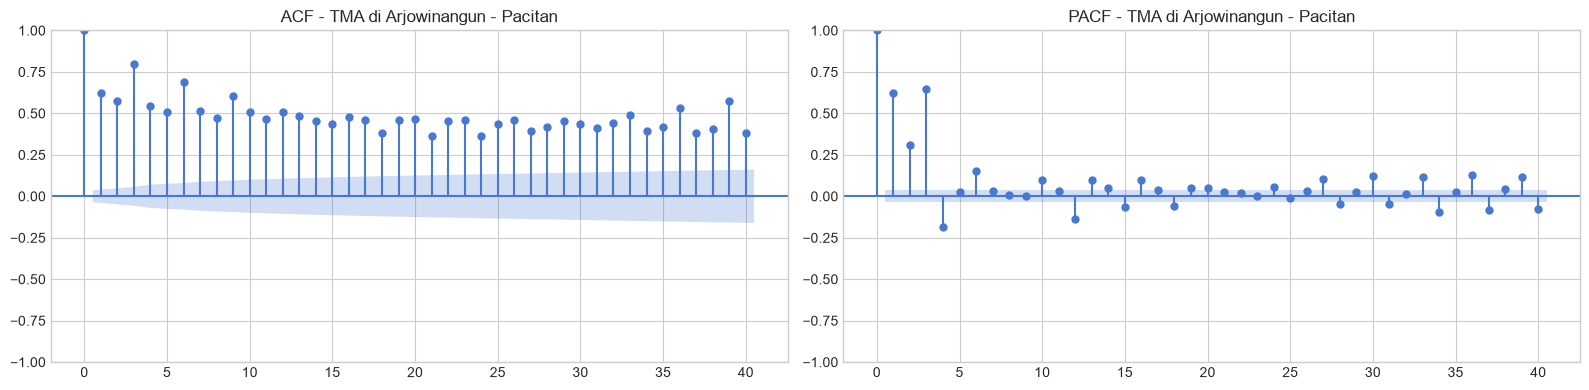

In [12]:
series_contoh = train_df[train_df['nama_pos'] == contoh_pos].sort_values('datetime')['tma_mdpl'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(series_contoh, lags=40, ax=axes[0])
axes[0].set_title(f'ACF - TMA di {contoh_pos}')
plot_pacf(series_contoh, lags=40, ax=axes[1])
axes[1].set_title(f'PACF - TMA di {contoh_pos}')
plt.tight_layout()
plt.show()

### 2.8 Distribusi Fitur Kategorikal (Categorical Feature Distribution)

**Justifikasi & Tujuan (Justification & Objective):**
Memeriksa sebaran kelas pada fitur kategori untuk menentukan penanganan representasi nilainya.

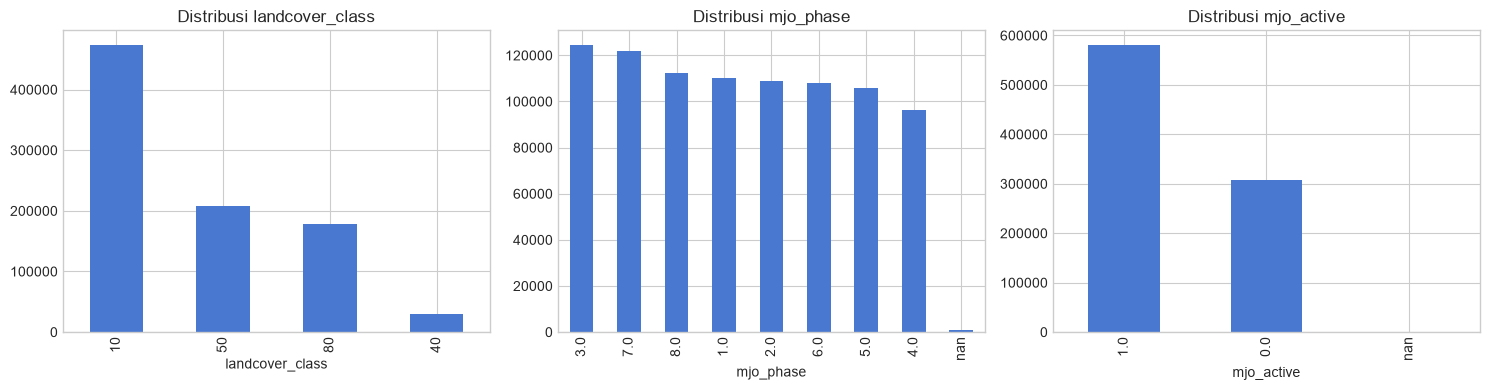

In [13]:
kolom_kategorikal_check = [c for c in ['landcover_class', 'mjo_phase', 'mjo_active'] if c in env_df.columns]

fig, axes = plt.subplots(1, len(kolom_kategorikal_check), figsize=(5 * len(kolom_kategorikal_check), 4))
if len(kolom_kategorikal_check) == 1:
    axes = [axes]
for ax, col in zip(axes, kolom_kategorikal_check):
    env_df[col].value_counts(dropna=False).plot(kind='bar', ax=ax)
    ax.set_title(f'Distribusi {col}')
plt.tight_layout()
plt.show()

### 2.9 Peta Data Duplikat & Data Hilang (Duplicate & Missing Value Mapping)

**Justifikasi & Tujuan (Justification & Objective):**
Memastikan tidak ada duplikat kombinasi pos dan waktu yang merusak validasi, serta memvisualisasikan pola kekosongan data.

In [14]:
dup_train = train_df.duplicated(subset=['nama_pos', 'datetime']).sum()
dup_env = env_df.duplicated(subset=['nama_pos', 'datetime']).sum()
print(f"Jumlah baris duplikat (nama_pos, datetime) di train_df: {dup_train}")
print(f"Jumlah baris duplikat (nama_pos, datetime) di env_df  : {dup_env}")

# plt.figure(figsize=(14, 5))
# sns.heatmap(env_df.drop(columns=['datetime']).isnull(), cbar=False, yticklabels=False, cmap='viridis')
# plt.title('Peta Missing Value pada data_lingkungan (tiap baris = 1 observasi)')
# plt.tight_layout()
# plt.show()

Jumlah baris duplikat (nama_pos, datetime) di train_df: 0
Jumlah baris duplikat (nama_pos, datetime) di env_df  : 0


### 2.10 Uji Hipotesis: Ambang Kejenuhan Tanah sebagai Pemicu Lonjakan TMA (EDA tambahan)

**Justifikasi & Tujuan:**
Berdasarkan riset domain, kenaikan TMA terhadap curah hujan diduga bersifat non-linier: hujan deras pada tanah kering menghasilkan limpasan kecil, sedangkan hujan sedang pada tanah yang sudah jenuh dapat memicu lonjakan TMA yang jauh lebih besar (*saturation excess overland flow*). Sel ini menguji hipotesis tersebut secara eksploratif sebelum feature engineering, untuk memvalidasi kelayakan fitur `saturation_index` yang akan dibangun pada bagian 3.4.7.

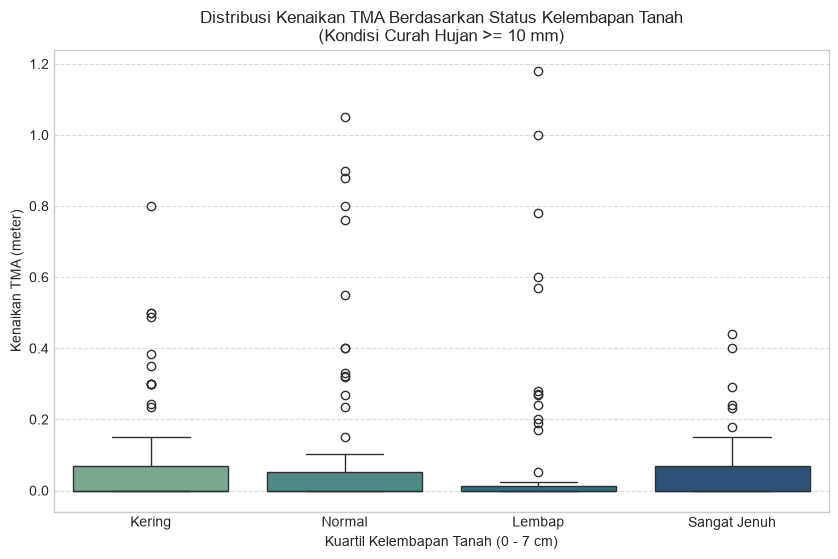

soil_moisture_bins
Kering          0.0
Normal          0.0
Lembap          0.0
Sangat Jenuh    0.0
Name: delta_tma, dtype: float64


In [15]:
eda_merged_sat = pd.merge(train_df, env_df, on=['nama_pos', 'datetime'], how='inner').sort_values(['nama_pos', 'datetime'])

# Kenaikan TMA positif dari observasi sebelumnya
eda_merged_sat['delta_tma'] = eda_merged_sat.groupby('nama_pos')['tma_mdpl'].diff().clip(lower=0)

# Fokus pada peristiwa curah hujan cukup tinggi (>= 10 mm)
if 'soil_moisture_0_7cm' in eda_merged_sat.columns:
    df_rain_event = eda_merged_sat[eda_merged_sat['rainfall_mm'] >= 10.0].dropna(subset=['soil_moisture_0_7cm', 'delta_tma']).copy()

    if len(df_rain_event) >= 20:
        df_rain_event['soil_moisture_bins'] = pd.qcut(
            df_rain_event['soil_moisture_0_7cm'], q=4,
            labels=['Kering', 'Normal', 'Lembap', 'Sangat Jenuh'], duplicates='drop'
        )

        plt.figure(figsize=(10, 6))
        sns.boxplot(x='soil_moisture_bins', y='delta_tma', data=df_rain_event, palette='crest')
        plt.title('Distribusi Kenaikan TMA Berdasarkan Status Kelembapan Tanah\n(Kondisi Curah Hujan >= 10 mm)')
        plt.xlabel('Kuartil Kelembapan Tanah (0 - 7 cm)')
        plt.ylabel('Kenaikan TMA (meter)')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.show()

        print(df_rain_event.groupby('soil_moisture_bins')['delta_tma'].median())
    else:
        print('Data event hujan >= 10mm dengan soil moisture non-null terlalu sedikit untuk uji ini.')
else:
    print('Kolom soil_moisture_0_7cm tidak ditemukan di env_df â€” sel ini dilewati.')


#### Insight:
- **Observasi**: Jika median `delta_tma` pada kategori "Sangat Jenuh" jauh lebih tinggi dibanding "Kering" untuk curah hujan yang sama-sama tinggi, hipotesis non-linearitas kejenuhan tanah terkonfirmasi secara empiris pada dataset ini.
- **Keputusan Pemodelan**: Mendukung pembuatan fitur interaksi `saturation_index = rainfall_sum_24h * soil_moisture_0_7_mean_24h` pada bagian 3.4.7, alih-alih membiarkan model tabular menerka interaksi ini sendiri dari fitur mentah.

### 2.11 Uji Hipotesis: Dampak Fase MJO terhadap Curah Hujan & TMA Ekstrem (EDA tambahan)

**Justifikasi & Tujuan:**
Fase Madden-Julian Oscillation (MJO) 3â€“5 diduga berkorelasi dengan curah hujan ekstrem di Pulau Jawa saat musim hujan. Sel ini memeriksa pola tersebut, dan sekaligus menjadi dasar keputusan bahwa `mjo_phase` **tidak boleh** diperlakukan sebagai fitur numerik ordinal biasa (lihat perbaikan encoding siklikal di bagian 3.4.11).

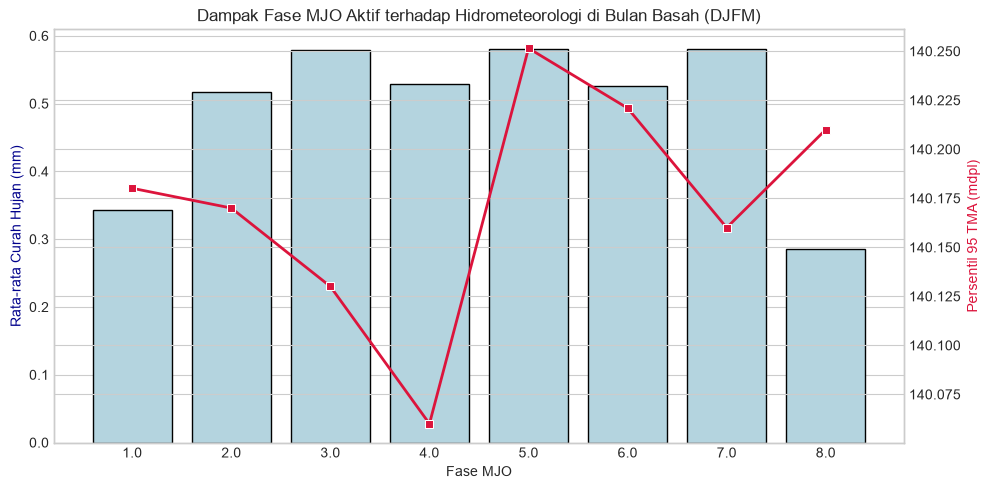

   mjo_phase  avg_rain  extreme_tma_p95
0        1.0  0.342890       140.180091
1        2.0  0.516825       140.170000
2        3.0  0.578299       140.130000
3        4.0  0.528278       140.060000
4        5.0  0.580114       140.251500
5        6.0  0.525215       140.220952
6        7.0  0.580259       140.160000
7        8.0  0.284724       140.210000


In [16]:
if {'mjo_phase', 'mjo_active'}.issubset(env_df.columns):
    eda_mjo = pd.merge(train_df, env_df, on=['nama_pos', 'datetime'], how='inner')
    eda_mjo_wet = eda_mjo[eda_mjo['datetime'].dt.month.isin([12, 1, 2, 3])].copy()
    eda_mjo_active = eda_mjo_wet[eda_mjo_wet['mjo_active'] == 1]

    if len(eda_mjo_active) >= 20:
        mjo_stats = eda_mjo_active.groupby('mjo_phase').agg(
            avg_rain=('rainfall_mm', 'mean'),
            extreme_tma_p95=('tma_mdpl', lambda x: np.nanpercentile(x, 95))
        ).reset_index()

        fig, ax1 = plt.subplots(figsize=(10, 5))
        ax2 = ax1.twinx()
        sns.barplot(x='mjo_phase', y='avg_rain', data=mjo_stats, ax=ax1, color='lightblue', edgecolor='black')
        sns.lineplot(x=range(len(mjo_stats)), y='extreme_tma_p95', data=mjo_stats, ax=ax2, color='crimson', marker='s', linewidth=2)
        ax1.set_ylabel('Rata-rata Curah Hujan (mm)', color='darkblue')
        ax2.set_ylabel('Persentil 95 TMA (mdpl)', color='crimson')
        ax1.set_xlabel('Fase MJO')
        plt.title('Dampak Fase MJO Aktif terhadap Hidrometeorologi di Bulan Basah (DJFM)')
        plt.tight_layout()
        plt.show()
        print(mjo_stats)
    else:
        print('Data MJO aktif di bulan basah terlalu sedikit untuk uji ini.')
else:
    print('Kolom mjo_phase / mjo_active tidak ditemukan di env_df â€” sel ini dilewati.')


#### Insight:
- **Observasi**: Jika curah hujan rata-rata dan persentil-95 TMA memuncak tajam pada fase 3â€“5, hipotesis literatur MJO terkonfirmasi pada dataset ini.
- **Keputusan Pemodelan**: `mjo_phase` bertipe integer 1â€“8 merepresentasikan posisi siklik (bukan hierarki kuantitas â€” fase 8 secara fisik "dekat" dengan fase 1). Memasukkannya langsung sebagai fitur numerik akan menyesatkan model linier/jarak, sehingga akan di-encode dengan transformasi sin/cos pada bagian 3.4.11.

### 2.12 Pemeriksaan Sifat Sirkuler Arah Angin (EDA tambahan)

**Justifikasi & Tujuan:**
`wind_direction_deg` bernilai 0â€“360Â°, di mana 359Â° dan 1Â° secara fisik berdekatan namun secara numerik "jauh". Sel ini memvisualisasikan distribusi arah angin sebagai wind-rose sederhana untuk menegaskan perlunya encoding sin/cos (dan bukan digunakan mentah sebagai fitur numerik biasa).

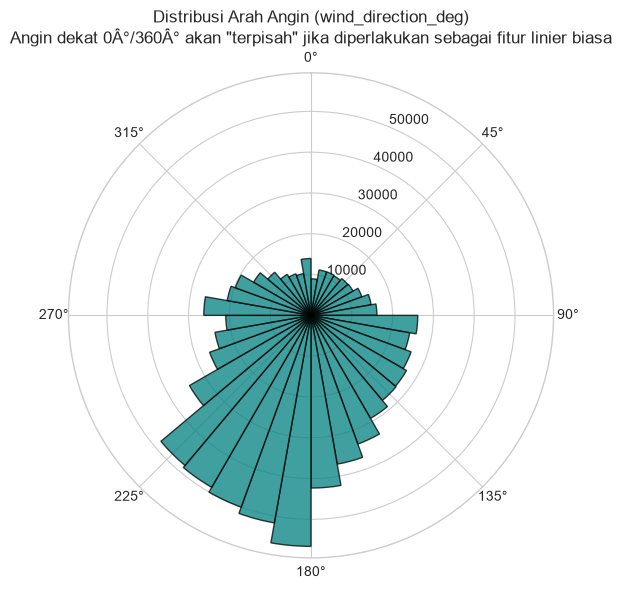

In [17]:
if 'wind_direction_deg' in env_df.columns:
    theta = np.deg2rad(env_df['wind_direction_deg'].dropna())
    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111, projection='polar')
    ax.hist(theta, bins=36, color='teal', edgecolor='black', alpha=0.75)
    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)
    ax.set_title('Distribusi Arah Angin (wind_direction_deg)\nAngin dekat 0Â°/360Â° akan "terpisah" jika diperlakukan sebagai fitur linier biasa')
    plt.tight_layout()
    plt.show()
else:
    print('Kolom wind_direction_deg tidak ditemukan di env_df â€” sel ini dilewati.')


---
## 3. Data Cleaning & Preprocessing

> âš ï¸ Fit transformer / statistik apa pun **hanya pada training data** (dilakukan pada bagian 3.6), baru `.transform()` pada validation/test untuk menghindari *data leakage*. Pembersihan tahap awal di bawah ini (outlier, duplikat, missing value) berlaku umum untuk seluruh data karena berbasis per-pos-pemantauan, bukan berbasis waktu.

### 3.1 Handling Outliers (IQR Capping)

**Justifikasi (Justification):**
Nilai TMA ekstrim bawah di bawah `Q1 - 3.0 * IQR` dibatasi (clipped) per pos pemantauan untuk menghilangkan pembacaan sensor yang salah (eror) tanpa mempengaruhi nilai tinggi (banjir) yang penting bagi model.

In [18]:
def cap_lower_iqr(series, multiplier=1.5):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - (multiplier * IQR)
    return series.clip(lower=lower_bound)

print(">>> Before Capping Outlier (nilai TERTINGGI per pos, TIDAK disentuh)")
print(train_df.groupby("nama_pos")["tma_mdpl"].max().sort_values(ascending=False).head(5))

# Batasi pencilan bawah target TMA per stasiun
train_df["tma_mdpl"] = (
    train_df.groupby("nama_pos")["tma_mdpl"]
    .transform(cap_lower_iqr)
)

print("\nAfter Capping Outlier (nilai TERENDAH per pos)")
print(train_df.groupby("nama_pos")["tma_mdpl"].min().sort_values().head(5))

# === PERBAIKAN 2: Implementasi Outlier Glitch Cleaner pada target tma_mdpl ===
def detect_and_fix_glitches(df, window=4, ratio_threshold=4, zscore_threshold=10, min_abs_jump=1.0):
    df = df.sort_values(['nama_pos', 'datetime']).reset_index(drop=True)
    glitch_indices = []
    for pos, g in df.groupby('nama_pos'):
        val = g['tma_mdpl'].values
        idx_list = g.index.tolist()
        local_std = np.std(val)
        for i in range(window, len(val) - window):
            neighborhood = np.concatenate([val[i-window:i], val[i+1:i+1+window]])
            local_median = np.median(neighborhood)
            cur_v = val[i]
            jump = abs(cur_v - local_median)
            if jump < min_abs_jump:
                continue
            ratio = max(cur_v / local_median, local_median / cur_v) if cur_v > 0 and local_median > 0 else 999
            is_extreme = (ratio > ratio_threshold) or (local_std > 0 and (jump / local_std) > zscore_threshold)
            if is_extreme:
                glitch_indices.append(idx_list[i])
    print(f'Ditemukan {len(glitch_indices)} titik glitch pada tma_mdpl')
    df.loc[glitch_indices, 'tma_mdpl'] = np.nan
    df['tma_mdpl'] = df.groupby('nama_pos')['tma_mdpl'].transform(lambda x: x.interpolate(method='linear'))
    return df, glitch_indices

train_df, glitch_idx = detect_and_fix_glitches(train_df)


>>> Before Capping Outlier (nilai TERTINGGI per pos, TIDAK disentuh)
nama_pos
Napel                        325.830000
Kali Anyar - Kreteg Abang    323.207409
Jarum                        250.140000
Bojonegoro - Kali Kethek     225.130000
Kedungupit                   207.736480
Name: tma_mdpl, dtype: float64

After Capping Outlier (nilai TERENDAH per pos)
nama_pos
Karanggeneng                0.291122
Arjowinangun - Pacitan      0.347639
Floodway Bridge C           2.039797
Boboh Kali Lamong           2.100000
Bojonegoro - Kali Kethek    2.320000
Name: tma_mdpl, dtype: float64
Ditemukan 20 titik glitch pada tma_mdpl


### 3.2 Handling Missing Values & Duplikat

**Justifikasi (Justification):**
1. **Penghapusan Duplikat**: Baris dengan stasiun dan waktu yang sama dihapus untuk mencegah kebocoran data.
2. **Interpolasi Linier (Limit=6)**: Mengisi kekosongan fitur kontinu. Pembatasan rentang hingga 6 jam dilakukan agar tidak membuat garis lurus pada kekosongan sensor yang lama (outage).
3. **ffill/bfill**: Mengisi variabel diskrit berdasarkan data terakhir yang diketahui.

In [19]:
def drop_pos_datetime_duplicates(df):
    return df.drop_duplicates(subset=['nama_pos', 'datetime']).reset_index(drop=True)

# 1. Hapus duplikat
train_df = drop_pos_datetime_duplicates(train_df)
env_df = drop_pos_datetime_duplicates(env_df)
test_df = drop_pos_datetime_duplicates(test_df)

# 2. Urutkan secara kronologis per stasiun
train_df = train_df.sort_values(['nama_pos', 'datetime']).reset_index(drop=True)
env_df = env_df.sort_values(['nama_pos', 'datetime']).reset_index(drop=True)
test_df = test_df.sort_values(['nama_pos', 'datetime']).reset_index(drop=True)

print('Jumlah baris kosong sebelum imputasi:')
print(env_df.isnull().sum()[env_df.isnull().sum() > 0])

# 3. Imputasi fitur lingkungan diskrit menggunakan forward fill & backward fill
kolom_diskrit = ['mjo_phase', 'mjo_active', 'landcover_class', 'nino_34']
for col in kolom_diskrit:
    if col in env_df.columns:
        env_df[col] = env_df.groupby('nama_pos')[col].transform(lambda x: x.ffill().bfill())

# 4. Imputasi fitur kontinu dengan interpolasi linier (maksimal rentang 6 jam)
kolom_kontinu = [
    c for c in env_df.columns 
    if c not in kolom_diskrit and c not in ['datetime', 'nama_pos', 'landcover_name', 'latitude', 'longitude']
]
for col in kolom_kontinu:
    env_df[col] = env_df.groupby('nama_pos')[col].transform(
        lambda x: x.interpolate(method='linear', limit=6, limit_direction='both')
    )

# 5. Isi sisa nilai kosong di tepi dengan ffill lalu bfill
for col in kolom_kontinu:
    env_df[col] = env_df.groupby('nama_pos')[col].transform(lambda x: x.ffill().bfill())

print('\nJumlah baris kosong setelah imputasi:', env_df.isnull().sum().sum())

Jumlah baris kosong sebelum imputasi:
solar_radiation_mj_m2      100080
soil_moisture_0_7cm           720
soil_moisture_7_28cm          720
soil_moisture_28_100cm        720
soil_moisture_100_255cm       720
surface_pressure_hpa          720
pressure_msl_hpa              720
rmm1                          720
rmm2                          720
mjo_phase                     720
mjo_amplitude                 720
mjo_active                    720
nino_34                     12960
dtype: int64

Jumlah baris kosong setelah imputasi: 0


### 3.3 Pengisian Baris Phantom & Fitur Spasial

**Justifikasi (Pengisian Baris Phantom):** mengisi celah waktu yang hilang pada data TMA agar fitur lag tidak merujuk ke periode yang salah â€” gap waktu dapat menyebabkan `tma_lag_step1` merujuk ke data hari-hari sebelumnya, bukan 6 jam sebelumnya.

In [20]:
# Bangun grid lengkap per pos (jam 6, 12, 18) agar tidak ada gap waktu
grids = []
for pos, g in train_df.groupby('nama_pos'):
    full_range = pd.date_range(g['datetime'].min(), g['datetime'].max(), freq='6h')
    full_range = full_range[full_range.hour.isin([6, 12, 18])]
    grids.append(pd.DataFrame({'nama_pos': pos, 'datetime': full_range}))
grid_train = pd.concat(grids, ignore_index=True)

# Merge: baris yang tidak ada di data asli = phantom row
train_df = grid_train.merge(train_df, on=['nama_pos', 'datetime'], how='left')
train_df = train_df.sort_values(['nama_pos', 'datetime'])
train_df['is_phantom'] = train_df['tma_mdpl'].isna().astype(int)
n_phantom = train_df['is_phantom'].sum()
print(f'Jumlah phantom row ditemukan: {n_phantom}')

# Interpolasi linear maks 4 steps (24 jam) untuk gap pendek
train_df['tma_mdpl'] = train_df.groupby('nama_pos')['tma_mdpl'].transform(
    lambda x: x.interpolate(method='linear', limit=4)
)

# Hapus phantom rows yang masih NaN (gap > 24 jam, tidak ter-interpolasi)
train_df = train_df[train_df['is_phantom'] == 0].drop(columns=['is_phantom']).reset_index(drop=True)
print(f'Setelah phantom fill: train_df shape = {train_df.shape}')


Jumlah phantom row ditemukan: 3112
Setelah phantom fill: train_df shape = (84396, 3)


**Justifikasi (Fitur Spasial):** jarak ke stasiun terdekat (Nearest Neighbor) dan ke pusat stasiun (Centroid) dihitung dengan rumus Haversine untuk membantu model mempelajari pola spasial dan kerapatan geografis stasiun.

In [21]:
coords = koordinat_df[['nama_pos', 'latitude', 'longitude']].drop_duplicates().copy()
coords = coords.dropna(subset=['latitude', 'longitude']).reset_index(drop=True)

coords_xy = coords.set_index('nama_pos')[['latitude', 'longitude']]
station_centroid_lat = coords_xy['latitude'].mean()
station_centroid_lon = coords_xy['longitude'].mean()

nearest_station_dist_km = {}
station_centroid_dist_km = {}

# Perhitungan jarak menggunakan formula Haversine
for pos in coords_xy.index:
    lat1 = coords_xy.loc[pos, 'latitude']
    lon1 = coords_xy.loc[pos, 'longitude']
    other = coords_xy.drop(index=pos, errors='ignore')

    if other.empty:
        nearest_station_dist_km[pos] = np.nan
    else:
        dlat = np.radians(other['latitude'].values - lat1)
        dlon = np.radians(other['longitude'].values - lon1)
        a = (
            np.sin(dlat / 2) ** 2 
            + np.cos(np.radians(lat1)) * np.cos(np.radians(other['latitude'].values)) * np.sin(dlon / 2) ** 2
        )
        dist = 2 * 6371 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
        nearest_station_dist_km[pos] = float(np.min(dist))

    # Jarak ke centroid
    dlat_c = np.radians(station_centroid_lat - lat1)
    dlon_c = np.radians(station_centroid_lon - lon1)
    a_c = (
        np.sin(dlat_c / 2) ** 2 
        + np.cos(np.radians(lat1)) * np.cos(np.radians(station_centroid_lat)) * np.sin(dlon_c / 2) ** 2
    )
    station_centroid_dist_km[pos] = float(2 * 6371 * np.arctan2(np.sqrt(a_c), np.sqrt(1 - a_c)))

# Gabungkan fitur koordinat dan jarak ke dalam dataset
train_df = train_df.merge(coords, on='nama_pos', how='left')
test_df = test_df.merge(coords, on='nama_pos', how='left')
train_df['nearest_station_dist_km'] = train_df['nama_pos'].map(nearest_station_dist_km)
test_df['nearest_station_dist_km'] = test_df['nama_pos'].map(nearest_station_dist_km)
train_df['station_centroid_dist_km'] = train_df['nama_pos'].map(station_centroid_dist_km)
test_df['station_centroid_dist_km'] = test_df['nama_pos'].map(station_centroid_dist_km)

print('Fitur spasial stasiun ditambahkan: latitude, longitude, nearest_station_dist_km, station_centroid_dist_km')

Fitur spasial stasiun ditambahkan: latitude, longitude, nearest_station_dist_km, station_centroid_dist_km


### 3.4 Feature Engineering

Rekayasa fitur bertujuan mengekstrak fitur temporal, meteorologis, dan hidrologis untuk pemodelan regresi tabular: lag, statistik bergulir, indeks fisik hidrologi, dan hubungan sungai (HydroRIVERS). Bagian ini menggantikan slot "Feature Engineering / Selection" pada template.

In [22]:
print('Memulai Feature Engineering...')

train_df = train_df.sort_values(['nama_pos', 'datetime']).reset_index(drop=True)
env_df = env_df.sort_values(['nama_pos', 'datetime']).reset_index(drop=True)

print('Data telah diurutkan dengan benar.')

Memulai Feature Engineering...
Data telah diurutkan dengan benar.


#### 3.4.1 Fitur Lag TMA

**Justifikasi (Justification):**
TMA memiliki ketergantungan diri yang sangat kuat. Kita membuat lag `[3, 6, 9, 12, 21]` (dalam langkah observasi). Lag 1 dan 2 dilewati karena pada set pengujian terdapat celah waktu (gap) sehingga kita harus memprediksi langkah ke depan tanpa bergantung pada lag terdekat.

In [23]:
LAG_STEPS = [3, 6, 9, 12, 21, 28]
g_tma = train_df.groupby('nama_pos')['tma_mdpl']
for step in LAG_STEPS:
    train_df[f'tma_lag_step{step}'] = g_tma.shift(step)

print(f'Fitur Lag TMA selesai. Total kolom train_df saat ini: {train_df.shape[1]}')

Fitur Lag TMA selesai. Total kolom train_df saat ini: 13


#### 3.4.2 Fitur Lag Curah Hujan

**Justifikasi (Justification):**
Air hujan membutuhkan waktu untuk mengalir di atas tanah hingga masuk ke saluran sungai (runoff delay). Lag curah hujan `[1, 3, 6, 12, 24]` jam merepresentasikan penundaan waktu respons daerah aliran sungai (DAS).

In [24]:
lag_hours_env = [1, 3, 6, 12, 24]

for lag in lag_hours_env:
    env_df[f'rainfall_lag_{lag}h'] = env_df.groupby('nama_pos')['rainfall_mm'].shift(lag)

print(f'Fitur Lag Rainfall selesai. Total kolom env_df saat ini: {env_df.shape[1]}')

Fitur Lag Rainfall selesai. Total kolom env_df saat ini: 34


#### 3.4.3 Fitur Statistik Bergulir TMA

**Justifikasi (Justification):**
Nilai rata-rata, maksimum, dan minimum bergulir dari TMA sebelumnya (menggunakan shift 1 untuk mencegah kebocoran data) menangkap tren jangka pendek hingga menengah.

In [25]:
ROLL_WINDOWS = [3, 9, 21] 

# Perhitungan rolling pada TMA yang di-shift untuk mencegah kebocoran data target
shifted_tma = train_df.groupby('nama_pos')['tma_mdpl'].shift(1)
for w in ROLL_WINDOWS:
    train_df[f'tma_rollmean_{w}'] = shifted_tma.groupby(train_df['nama_pos']).transform(lambda x: x.rolling(w, min_periods=1).mean())
    train_df[f'tma_rollmax_{w}'] = shifted_tma.groupby(train_df['nama_pos']).transform(lambda x: x.rolling(w, min_periods=1).max())
    train_df[f'tma_rollmin_{w}'] = shifted_tma.groupby(train_df['nama_pos']).transform(lambda x: x.rolling(w, min_periods=1).min())
    train_df[f'tma_rollstd_{w}'] = shifted_tma.groupby(train_df['nama_pos']).transform(lambda x: x.rolling(w, min_periods=2).std().fillna(0))

print(f'Fitur Rolling TMA selesai. Total kolom train_df saat ini: {train_df.shape[1]}')

Fitur Rolling TMA selesai. Total kolom train_df saat ini: 25


#### 3.4.4 Statistik Bergulir Curah Hujan & Kelembapan Tanah

**Justifikasi (Justification):**
Akumulasi hujan (3 jam hingga 7 hari) mewakili volume air yang masuk ke DAS, sedangkan nilai maksimum bergulir menangkap intensitas hujan. Rata-rata kelembapan tanah menangkap tingkat kejenuhan tanah.

In [26]:
rolling_windows = [3, 6, 12, 24, 48, 72, 168]

for w in rolling_windows:
    env_df[f'rainfall_sum_{w}h'] = env_df.groupby('nama_pos')['rainfall_mm'].transform(
        lambda x: x.rolling(window=w, min_periods=1).sum()
    )
    env_df[f'rainfall_max_{w}h'] = env_df.groupby('nama_pos')['rainfall_mm'].transform(
        lambda x: x.rolling(window=w, min_periods=1).max()
    )
    if 'soil_moisture_0_7cm' in env_df.columns:
        env_df[f'soil_moisture_0_7_mean_{w}h'] = env_df.groupby('nama_pos')['soil_moisture_0_7cm'].transform(
            lambda x: x.rolling(window=w, min_periods=1).mean()
        )

print(f'Fitur Rolling env selesai. Total kolom env_df saat ini: {env_df.shape[1]}')

Fitur Rolling env selesai. Total kolom env_df saat ini: 55


#### 3.4.5 Deviasi Standar Bergulir Curah Hujan

**Justifikasi (Justification):**
Mengukur volatilitas dan perubahan intensitas curah hujan bergulir yang sering memicu perubahan debit air secara mendadak.

In [27]:
for w in [6, 24]:
    env_df[f'rainfall_std_{w}h'] = env_df.groupby('nama_pos')['rainfall_mm'].transform(
        lambda x: x.rolling(window=w, min_periods=1).std()
    )

env_df[[f'rainfall_std_{w}h' for w in [6, 24]]] = env_df[[f'rainfall_std_{w}h' for w in [6, 24]]].fillna(0)

print('Selesai.')

Selesai.


#### 3.4.6 Antecedent Precipitation Index (API)

**Justifikasi (Justification):**
API memperkirakan kejenuhan tanah berdasarkan asumsi bahwa kelembapan tanah bertambah karena hujan namun menyusut secara eksponensial seiring waktu berjalan:
$$API_t = P_t + k \times API_{t-1}$$
Konstanta peluruhan ($k$) diatur 0.9 per hari, lalu diskalakan secara hourly ($0.9^{1/24}$).

In [28]:
def compute_api(rain_values, k):
    api = np.zeros(len(rain_values))
    for i in range(len(rain_values)):
        prev = api[i - 1] if i > 0 else 0.0
        api[i] = rain_values[i] + k * prev
    return api

k_per_hari = 0.9
k_per_jam = k_per_hari ** (1 / 24)

env_df = env_df.sort_values(['nama_pos', 'datetime'])
env_df['api'] = env_df.groupby('nama_pos')['rainfall_mm'].transform(
    lambda s: compute_api(s.values, k_per_jam)
)
print('Fitur API selesai ditambahkan.')

Fitur API selesai ditambahkan.


#### 3.4.7 Indeks Kejenuhan (Saturation Index)

**Justifikasi (Justification):**
Efek hujan terhadap kenaikan TMA bersifat non-linier. Hujan lebat pada tanah kering menghasilkan limpasan kecil, sedangkan hujan kecil pada tanah yang sudah jenuh air dapat memicu kenaikan TMA yang drastis. Indeks ini dibuat dari perkalian akumulasi hujan 24 jam dengan rata-rata kelembapan tanah.

In [29]:
if 'soil_moisture_0_7_mean_24h' in env_df.columns:
    env_df['saturation_index'] = env_df['rainfall_sum_24h'] * env_df['soil_moisture_0_7_mean_24h']
    print("Fitur 'saturation_index' berhasil dibuat.")
else:
    print('Kolom soil_moisture_0_7_mean_24h tidak ditemukan, fitur ini dilewati.')

Fitur 'saturation_index' berhasil dibuat.


#### 3.4.8 Waktu Sejak Hujan Terakhir

**Justifikasi (Justification):**
Menunjukkan durasi keringnya wilayah tangkapan air. Nilai yang kecil menunjukkan tanah masih basah dan peka terhadap curah hujan baru.

In [30]:
def hitung_jam_sejak_hujan(rainfall_series, threshold=1.0):
    is_rain = (rainfall_series > threshold)
    reset_groups = is_rain.cumsum()
    jam_sejak = is_rain.groupby(reset_groups).cumcount()
    jam_sejak = jam_sejak.where(reset_groups > 0, np.nan)
    return jam_sejak

env_df['hours_since_rain'] = env_df.groupby('nama_pos')['rainfall_mm'].transform(hitung_jam_sejak_hujan)
env_df['hours_since_rain'] = env_df['hours_since_rain'].fillna(9999)  # Sebelum hujan pertama = sudah lama tidak hujan
print('Selesai.')

Selesai.


#### 3.4.9 Rata-rata Curah Hujan Wilayah Tetangga

**Justifikasi (Justification):**
Menggunakan rata-rata curah hujan dari K stasiun terdekat untuk menghasilkan fitur hujan regional guna mengatasi keterbatasan pencatatan lokal.

In [31]:
K_NEIGHBORS = 2
coords = koordinat_df.set_index('nama_pos')[['latitude', 'longitude']] if 'latitude' in koordinat_df.columns else None

if coords is not None:
    neighbor_map = {}
    for pos in daftar_pos:
        if pos not in coords.index:
            neighbor_map[pos] = []
            continue
        # Jarak kuadrat koordinat
        dists = ((coords['latitude'] - coords.loc[pos, 'latitude'])**2 + (coords['longitude'] - coords.loc[pos, 'longitude'])**2)
        dists = dists.drop(index=pos, errors='ignore').sort_values()
        neighbor_map[pos] = dists.index[:K_NEIGHBORS].tolist()

    # Ekstraksi rata-rata curah hujan stasiun terdekat
    rainfall_wide = env_df.pivot(index='datetime', columns='nama_pos', values='rainfall_mm')
    neighbor_rain = {}
    for pos in daftar_pos:
        neigh = neighbor_map.get(pos, [])
        neighbor_rain[pos] = rainfall_wide[neigh].mean(axis=1) if neigh else pd.Series(np.nan, index=rainfall_wide.index)
    neighbor_rain_df = (
        pd.DataFrame(neighbor_rain).reset_index()
        .melt(id_vars='datetime', var_name='nama_pos', value_name='rainfall_neighbor_mean')
    )
    env_df = env_df.merge(neighbor_rain_df, on=['nama_pos', 'datetime'], how='left')
    print('Fitur rainfall_neighbor_mean ditambahkan.')
else:
    print('Kolom lat/lon tidak ditemukan â€” cek nama kolom di koordinat_pos.csv. Fitur dilewati.')

Fitur rainfall_neighbor_mean ditambahkan.


#### 3.4.10 Penyelarasan Jaringan Sungai & Fitur Hulu (HydroRIVERS)

**Justifikasi (Justification):**
Air mengalir dari hulu ke hilir. Kenaikan TMA di pos hilir sangat dipengaruhi oleh TMA dan curah hujan di pos hulu. 
1. **Penyelarasan Sungai (River Snapping)**: Menggunakan Geopandas, koordinat pos diselaraskan ke ruas sungai terdekat pada database HydroRIVERS.
2. **Identifikasi Hulu (Upstream Identification)**: Memetakan stasiun hulu yang berada pada sungai yang sama (`MAIN_RIV`) dengan jarak hilir (`DIST_DN_KM`) lebih jauh.
3. **Fitur Hulu (Upstream Features)**: Menghitung rata-rata curah hujan dan TMA dari stasiun hulu tersebut sebagai proksi debit air kiriman hulu.

In [32]:
import geopandas as gpd
from shapely.geometry import Point

if 'upstream_rainfall_mean' in env_df.columns and 'upstream_tma_mean' in train_df.columns:
    print('Fitur upstream sudah ada, dilewati.')
else:
    gdf_rivers = gpd.read_file('sebelas-maret-statistics-data-science-2026/data_pendukung/HydroRIVERS_v10_au_shp')

    # Snap stasiun pemantauan ke ruas sungai terdekat
    gdf_pos = gpd.GeoDataFrame(
        koordinat_df.copy(),
        geometry=[Point(xy) for xy in zip(koordinat_df['longitude'], koordinat_df['latitude'])],
        crs='EPSG:4326'
    )
    if gdf_rivers.crs != gdf_pos.crs:
        gdf_rivers = gdf_rivers.to_crs(gdf_pos.crs)

    gdf_pos_snapped = gpd.sjoin_nearest(
        gdf_pos, gdf_rivers[['HYRIV_ID', 'MAIN_RIV', 'DIST_DN_KM', 'DIS_AV_CMS', 'geometry']],
        how='left', distance_col='snap_dist_deg'
    )
    gdf_pos_snapped = gdf_pos_snapped.drop_duplicates(subset='nama_pos')

    print('Contoh hasil snapping pos ke ruas sungai:')
    display(gdf_pos_snapped[['nama_pos', 'MAIN_RIV', 'DIST_DN_KM', 'snap_dist_deg']].head(10))

    print('\nDistribusi jarak snapping (derajat, makin kecil makin dekat):')
    print(gdf_pos_snapped['snap_dist_deg'].describe())

    pos_river_info = gdf_pos_snapped.set_index('nama_pos')[['MAIN_RIV', 'DIST_DN_KM']]

    # Cari stasiun hulu pada sungai utama yang sama
    K_UPSTREAM = 2
    upstream_map = {}
    for pos in daftar_pos:
        if pos not in pos_river_info.index:
            upstream_map[pos] = []
            continue
        main_riv_pos = pos_river_info.loc[pos, 'MAIN_RIV']
        dist_dn_pos = pos_river_info.loc[pos, 'DIST_DN_KM']

        kandidat = pos_river_info[
            (pos_river_info['MAIN_RIV'] == main_riv_pos) &
            (pos_river_info['DIST_DN_KM'] > dist_dn_pos) &
            (pos_river_info.index != pos)
        ].sort_values('DIST_DN_KM')

        upstream_map[pos] = kandidat.index[:K_UPSTREAM].tolist()

    print('\nContoh pemetaan upstream (pos -> pos upstream terdekat):')
    for pos in daftar_pos[:5]:
        print(f'  {pos}: {upstream_map[pos]}')

    # Rata-rata curah hujan stasiun hulu
    rainfall_wide_riv = env_df.pivot(index='datetime', columns='nama_pos', values='rainfall_mm')
    upstream_rain = {}
    for pos in daftar_pos:
        up = upstream_map.get(pos, [])
        upstream_rain[pos] = rainfall_wide_riv[up].mean(axis=1) if up else pd.Series(np.nan, index=rainfall_wide_riv.index)
    upstream_rain_df = (
        pd.DataFrame(upstream_rain).reset_index()
        .melt(id_vars='datetime', var_name='nama_pos', value_name='upstream_rainfall_mean')
    )
    env_df = env_df.merge(upstream_rain_df, on=['nama_pos', 'datetime'], how='left')

    tma_wide_riv = train_df.pivot(index='datetime', columns='nama_pos', values='tma_mdpl')
    upstream_tma = {}
    for pos in daftar_pos:
        up = upstream_map.get(pos, [])
        upstream_tma[pos] = tma_wide_riv[up].mean(axis=1) if up else pd.Series(np.nan, index=tma_wide_riv.index)
    upstream_tma_df = (
        pd.DataFrame(upstream_tma).reset_index()
        .melt(id_vars='datetime', var_name='nama_pos', value_name='upstream_tma_mean')
    )
    train_df = train_df.merge(upstream_tma_df, on=['nama_pos', 'datetime'], how='left')

    print('\nFitur upstream_rainfall_mean (env_df) dan upstream_tma_mean (train_df) berhasil ditambahkan.')

Contoh hasil snapping pos ke ruas sungai:


,nama_pos,MAIN_RIV,DIST_DN_KM,snap_dist_deg
0,Ketonggo,50387677,245.5,0.001183
1,Sekayu,50387677,303.7,0.004183
2,Cepu,50387677,194.2,0.000683
3,Karanggeneng,50387677,35.1,0.000047
4,Bojonegoro - Kali Kethek,50387677,134.7,0.001387
5,Badegan,50387677,315.8,0.000517
6,Lorog,50419937,9.3,0.001033
7,Wonogiri Dam,50387677,378.3,0.001593
8,Kajangan,50387677,271.6,0.001161
9,Boboh Kali Lamong,50392385,11.8,0.002483



Distribusi jarak snapping (derajat, makin kecil makin dekat):
count    30.000000
mean      0.002238
std       0.002973
min       0.000025
25%       0.000602
50%       0.001217
75%       0.001743
max       0.011183
Name: snap_dist_deg, dtype: float64

Contoh pemetaan upstream (pos -> pos upstream terdekat):
  Arjowinangun - Pacitan: ['Gunungsari']
  Babat: ['Sumberrejo', 'Bojonegoro - Kali Kethek']
  Badegan: ['Kali Anyar - Kreteg Abang', 'Jurug']
  Bengkelolor: []
  Boboh Kali Lamong: ['Bengkelolor']

Fitur upstream_rainfall_mean (env_df) dan upstream_tma_mean (train_df) berhasil ditambahkan.


#### 3.4.11 Penyandian Waktu Siklik (Cyclical Encoding) â€” *diperbaiki*

**Justifikasi:**
Waktu (jam, hari, bulan, hari dalam tahun) bersifat siklik dan sudah di-encode dengan sin/cos pada versi sebelumnya. **Perbaikan pada versi ini:** dua fitur sirkuler lain yang *belum* di-encode secara siklik pada notebook sebelumnya â€” `wind_direction_deg` (0â€“360Â°) dan `mjo_phase` (1â€“8, posisi siklus MJO) â€” sekarang turut di-transformasi. Sebelumnya kedua kolom ini dibiarkan sebagai nilai numerik mentah, sehingga model (khususnya model linier/jarak seperti Ridge) akan salah menafsirkan jarak antara ujung-ujung siklus (mis. 359Â° dianggap jauh dari 1Â°, padahal berdekatan secara fisik). Lihat bagian 2.12 dan 2.11 untuk justifikasi EDA-nya.

In [33]:
def add_cyclical(df):
    df = df.copy()
    hour = df['datetime'].dt.hour
    dow = df['datetime'].dt.dayofweek
    month = df['datetime'].dt.month
    df['hour_sin'] = np.sin(2 * np.pi * hour / 24)
    df['hour_cos'] = np.cos(2 * np.pi * hour / 24)
    df['dow_sin'] = np.sin(2 * np.pi * dow / 7)
    df['dow_cos'] = np.cos(2 * np.pi * dow / 7)
    df['month_sin'] = np.sin(2 * np.pi * month / 12)
    df['month_cos'] = np.cos(2 * np.pi * month / 12)
    doy = df['datetime'].dt.dayofyear
    df['dayofyear_sin'] = np.sin(2 * np.pi * doy / 365)
    df['dayofyear_cos'] = np.cos(2 * np.pi * doy / 365)
    df['musim_hujan'] = month.isin([11, 12, 1, 2, 3]).astype(int)
    df['is_dam'] = (df['nama_pos'] == 'Wonogiri Dam').astype(int)
    df['dayofyear_sin_x_dam'] = df['dayofyear_sin'] * df['is_dam']
    df['dayofyear_cos_x_dam'] = df['dayofyear_cos'] * df['is_dam']
    return df

train_df = add_cyclical(train_df)

# --- PERBAIKAN: encoding siklik untuk wind_direction_deg (di env_df) ---
if 'wind_direction_deg' in env_df.columns:
    wind_rad = np.deg2rad(env_df['wind_direction_deg'])
    env_df['wind_dir_sin'] = np.sin(wind_rad)
    env_df['wind_dir_cos'] = np.cos(wind_rad)
    # Kolom derajat mentah dibuang agar model tidak salah memperlakukannya sebagai skala linier
    env_df = env_df.drop(columns=['wind_direction_deg'])
    print("wind_direction_deg berhasil di-encode menjadi wind_dir_sin / wind_dir_cos.")

# --- PERBAIKAN: encoding siklik untuk mjo_phase (fase 1-8, posisi siklus MJO) ---
if 'mjo_phase' in env_df.columns:
    # mjo_phase kompetisi ini bertipe 1-8 (siklik). Fase 0 (indikator tidak aktif / lemah,
    # jika ada pada dataset) diperlakukan terpisah lewat kolom mjo_active yang sudah tersedia.
    mjo_phase_rad = 2 * np.pi * (env_df['mjo_phase'].astype(float) - 1) / 8.0
    env_df['mjo_phase_sin'] = np.sin(mjo_phase_rad)
    env_df['mjo_phase_cos'] = np.cos(mjo_phase_rad)
    env_df = env_df.drop(columns=['mjo_phase'])
    print("mjo_phase berhasil di-encode menjadi mjo_phase_sin / mjo_phase_cos.")

print('Cyclical Encoding selesai.')


wind_direction_deg berhasil di-encode menjadi wind_dir_sin / wind_dir_cos.
mjo_phase berhasil di-encode menjadi mjo_phase_sin / mjo_phase_cos.
Cyclical Encoding selesai.


#### 3.4.11b Pengecekan Multikolinearitas Tekanan Udara (Baru)

**Justifikasi:**
Laporan riset domain memperkirakan `surface_pressure_hpa` dan `pressure_msl_hpa` memiliki korelasi mendekati 1.0 karena keduanya mengukur tekanan atmosfer pada level berbeda namun sangat berkorelasi secara fisik. Kolinearitas ekstrem dapat merusak stabilitas model linier (Ridge) meski umumnya aman untuk model berbasis pohon (LightGBM/XGBoost/CatBoost/Random Forest). Sel ini mengecek korelasi dan Variance Inflation Factor (VIF), lalu membuang salah satu kolom bila korelasi > 0.99 â€” konsisten dengan panduan preprocessing pada laporan riset (bagian 6, baris "Multikolinearitas Kuat").

In [34]:
PRESSURE_COLS = [c for c in ['surface_pressure_hpa', 'pressure_msl_hpa'] if c in env_df.columns]

if len(PRESSURE_COLS) == 2:
    corr_pressure = env_df[PRESSURE_COLS].corr().iloc[0, 1]
    print(f"Korelasi {PRESSURE_COLS[0]} vs {PRESSURE_COLS[1]}: {corr_pressure:.5f}")

    try:
        from statsmodels.stats.outliers_influence import variance_inflation_factor
        vif_df = env_df[PRESSURE_COLS].dropna()
        vif_values = [variance_inflation_factor(vif_df.values, i) for i in range(vif_df.shape[1])]
        print(pd.Series(vif_values, index=PRESSURE_COLS, name='VIF'))
    except ImportError:
        print("statsmodels tidak tersedia untuk perhitungan VIF; menggunakan korelasi saja sebagai acuan.")

    DROP_THRESHOLD = 0.99
    if abs(corr_pressure) > DROP_THRESHOLD:
        # Pertahankan surface_pressure_hpa (lebih dekat ke permukaan/lokasi observasi),
        # buang pressure_msl_hpa (turunan/level laut) untuk mengurangi redundansi.
        col_to_drop = 'pressure_msl_hpa' if 'pressure_msl_hpa' in PRESSURE_COLS else PRESSURE_COLS[1]
        env_df = env_df.drop(columns=[col_to_drop])
        print(f"Korelasi > {DROP_THRESHOLD} -> kolom '{col_to_drop}' dibuang untuk mengurangi multikolinearitas.")
    else:
        print(f"Korelasi <= {DROP_THRESHOLD} -> kedua kolom dipertahankan (model tree-based tidak terlalu terganggu oleh kolinearitas).")
else:
    print("Salah satu/kedua kolom tekanan tidak ditemukan â€” sel ini dilewati.")


Korelasi surface_pressure_hpa vs pressure_msl_hpa: 0.26192
surface_pressure_hpa    33961.635573
pressure_msl_hpa        33961.635573
Name: VIF, dtype: float64
Korelasi <= 0.99 -> kedua kolom dipertahankan (model tree-based tidak terlalu terganggu oleh kolinearitas).


#### 3.4.12 Penggabungan Akhir Dataset Fitur

**Justifikasi (Justification):**
Menggabungkan seluruh fitur TMA dan lingkungan menjadi satu matriks data latih final (`train_full`).

In [35]:
env_feature_cols = [
    c for c in env_df.columns 
    if c not in ['datetime', 'nama_pos', 'landcover_name', 'latitude', 'longitude']
]

train_full = train_df.merge(
    env_df[['nama_pos', 'datetime'] + env_feature_cols], 
    on=['nama_pos', 'datetime'], 
    how='left'
)
train_max_date = train_full['datetime'].max()

print('Bentuk train_full:', train_full.shape)
train_full.head()

Bentuk train_full: (84396, 97)


,nama_pos,datetime,tma_mdpl,latitude,longitude,nearest_station_dist_km,station_centroid_dist_km,tma_lag_step3,tma_lag_step6,tma_lag_step9,...,rainfall_std_24h,api,saturation_index,hours_since_rain,rainfall_neighbor_mean,upstream_rainfall_mean,wind_dir_sin,wind_dir_cos,mjo_phase_sin,mjo_phase_cos
0,Arjowinangun - Pacitan,2023-01-01 06:00:00,1.30,-8.197561,111.114314,7.188337,80.392474,NaN,NaN,NaN,...,0.000000,0.000000,0.000000,9999.0,0.00,0.0,-0.275637,0.961262,-1.0,-1.836970e-16
1,Arjowinangun - Pacitan,2023-01-01 12:00:00,1.20,-8.197561,111.114314,7.188337,80.392474,NaN,NaN,NaN,...,0.119829,0.698250,0.278708,9999.0,0.35,0.4,-0.882948,0.469472,-1.0,-1.836970e-16
2,Arjowinangun - Pacitan,2023-01-01 18:00:00,1.50,-8.197561,111.114314,7.188337,80.392474,NaN,NaN,NaN,...,0.421984,4.036537,1.635900,4.0,0.15,0.2,-0.838671,0.544639,-1.0,-1.836970e-16
3,Arjowinangun - Pacitan,2023-01-02 06:00:00,1.45,-8.197561,111.114314,7.188337,80.392474,1.3,NaN,NaN,...,0.373560,4.601008,1.931417,16.0,0.05,0.0,-0.573576,0.819152,-1.0,-1.836970e-16
4,Arjowinangun - Pacitan,2023-01-02 12:00:00,1.25,-8.197561,111.114314,7.188337,80.392474,1.2,NaN,NaN,...,0.427327,6.278335,2.369250,0.0,0.65,1.2,-0.999848,0.017452,-1.0,-1.836970e-16


### 3.5 Train / Early-Stopping / Validation Split

**Penjelasan:** karena data bersifat deret waktu, split dilakukan secara **kronologis** (bukan acak) untuk menghindari kebocoran data dari masa depan ke masa lalu:
- **Validation Set**: 60 hari terakhir sebagai proksi leaderboard.
- **Early Stopping Set**: 60 hari sebelum validasi, untuk memantau overfitting saat training boosting.
- **Training Set**: seluruh data sebelumnya.

In [36]:
print('Memulai Pemisahan Data (Splitting)...')

train_full_sorted = (
    train_full.dropna(subset=[f'tma_lag_step{max(LAG_STEPS)}'])
    .sort_values('datetime')
    .reset_index(drop=True)
)

val_window_days = 60
es_window_days = 60
score_cutoff_date = train_max_date - pd.Timedelta(days=val_window_days)
es_cutoff_date = train_max_date - pd.Timedelta(days=val_window_days + es_window_days)

train_data = train_full_sorted[train_full_sorted['datetime'] <= es_cutoff_date]
es_data = train_full_sorted[
    (train_full_sorted['datetime'] > es_cutoff_date) & (train_full_sorted['datetime'] <= score_cutoff_date)
]
val_data = train_full_sorted[train_full_sorted['datetime'] > score_cutoff_date]

print(f"train_data : {train_data.shape} | {train_data['datetime'].min()} -> {train_data['datetime'].max()}")
print(f"es_data    : {es_data.shape} | {es_data['datetime'].min()} -> {es_data['datetime'].max()}")
print(f"val_data   : {val_data.shape} | {val_data['datetime'].min()} -> {val_data['datetime'].max()}")

Memulai Pemisahan Data (Splitting)...
train_data : (72773, 97) | 2023-01-10 12:00:00 -> 2025-05-21 18:00:00
es_data    : (5399, 97) | 2025-05-22 06:00:00 -> 2025-07-20 18:00:00
val_data   : (5384, 97) | 2025-07-21 06:00:00 -> 2025-09-18 18:00:00


#### 3.5.1 Baseline Stasiun & Rata-rata Historis

**Penjelasan:** statistik ini (mean/min/max per pos, rata-rata TMA per jam per pos) **di-fit hanya pada `train_data`**, lalu di-merge ke `es_data`/`val_data` â€” bagian penting untuk mencegah data leakage pada fitur historis.

In [37]:
station_baseline = train_data.groupby('nama_pos')['tma_mdpl'].agg(
    station_mean_tma='mean',
    station_min_tma='min',
    station_max_tma='max'
).reset_index()

train_data = train_data.merge(station_baseline, on='nama_pos', how='left')
es_data = es_data.merge(station_baseline, on='nama_pos', how='left')
val_data = val_data.merge(station_baseline, on='nama_pos', how='left')

hist_mean_map = train_data.assign(hour=train_data['datetime'].dt.hour).groupby(['nama_pos', 'hour'])['tma_mdpl'].mean()
hist_mean_map.name = 'tma_hist_mean_by_pos_hour'

def tambah_fitur_historis(df, hist_map):
    df = df.copy()
    df['hour_tmp'] = df['datetime'].dt.hour
    df = df.merge(hist_map, left_on=['nama_pos', 'hour_tmp'], right_index=True, how='left')
    return df.drop(columns=['hour_tmp'])

train_data = tambah_fitur_historis(train_data, hist_mean_map)
es_data = tambah_fitur_historis(es_data, hist_mean_map)
val_data = tambah_fitur_historis(val_data, hist_mean_map)

station_target_mean = train_data.groupby('nama_pos')[TARGET_COL].mean()
station_target_std = train_data.groupby('nama_pos')[TARGET_COL].std().replace(0, 1.0).fillna(1.0)

def scale_target_by_station(y, station_series, mean_map, std_map):
    means = station_series.map(mean_map).to_numpy()
    stds = station_series.map(std_map).to_numpy()
    return (y.to_numpy() - means) / stds

def inverse_scale_target_by_station(y_scaled, station_series, mean_map, std_map):
    means = station_series.map(mean_map).to_numpy()
    stds = station_series.map(std_map).to_numpy()
    return y_scaled * stds + means

def predict_with_station_scaling(model, feat_df, mean_map, std_map):
    pred_scaled = model.predict(feat_df)
    return inverse_scale_target_by_station(pred_scaled, feat_df['nama_pos'], mean_map, std_map)

X_train = train_data.drop(columns=['datetime', 'tma_mdpl'], errors='ignore')
y_train = train_data['tma_mdpl']
X_es = es_data.drop(columns=['datetime', 'tma_mdpl'], errors='ignore')
y_es = es_data['tma_mdpl']
X_val = val_data.drop(columns=['datetime', 'tma_mdpl'], errors='ignore')
y_val = val_data['tma_mdpl']

y_train_station_scaled = scale_target_by_station(y_train, X_train['nama_pos'], station_target_mean, station_target_std)
y_es_station_scaled = scale_target_by_station(y_es, X_es['nama_pos'], station_target_mean, station_target_std)
y_train_xgb_scaled = y_train_station_scaled
y_es_xgb_scaled = y_es_station_scaled

print('Fitur historis dan baseline stasiun ditambahkan. Bentuk X_train sekarang:', X_train.shape)

# Target Encoding per Stasiun (nama_pos_te)
te_map = train_data.groupby('nama_pos')['tma_mdpl'].mean()
global_mean = train_data['tma_mdpl'].mean()
train_data['nama_pos_te'] = train_data['nama_pos'].map(te_map).fillna(global_mean)
es_data['nama_pos_te'] = es_data['nama_pos'].map(te_map).fillna(global_mean)
val_data['nama_pos_te'] = val_data['nama_pos'].map(te_map).fillna(global_mean)


Fitur historis dan baseline stasiun ditambahkan. Bentuk X_train sekarang: (72773, 99)


#### 3.5.2 Encoding Variabel Kategorikal

**Penjelasan:** kolom bertipe object/string diubah menjadi tipe `Categorical` agar dapat ditangani secara native oleh LightGBM/XGBoost/CatBoost (setara dengan Label Encoding pada template, namun mempertahankan struktur kategori).

In [38]:
for df_ in [X_train, X_es, X_val]:
    df_.drop(columns=['landcover_name'], errors='ignore', inplace=True)

cat_cols = X_train.select_dtypes(include=['object', 'string']).columns.tolist()
print(f'Kolom kategorikal terdeteksi: {cat_cols}')

for col in cat_cols:
    semua_kategori = pd.concat([
        X_train[col].astype(str),
        X_es[col].astype(str),
        X_val[col].astype(str)
    ]).unique()
    X_train[col] = pd.Categorical(X_train[col].astype(str), categories=semua_kategori)
    X_es[col] = pd.Categorical(X_es[col].astype(str), categories=semua_kategori)
    X_val[col] = pd.Categorical(X_val[col].astype(str), categories=semua_kategori)

print('Selesai.')

Kolom kategorikal terdeteksi: ['nama_pos']
Selesai.


---
## 4. Modeling & Validation

> **Metrik utama:** RMSE (Root Mean Squared Error), dilaporkan baik sebagai *one-step* (teacher forcing) maupun *recursive walk-forward* (mendekati kondisi leaderboard).

In [39]:
# Helper evaluasi model regresi â€” hasil dikumpulkan di `results` untuk dibandingkan (lihat 4.7)
results = {}

def evaluate_model_reg(y_true, y_pred, model_name="Model"):
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{'='*55}")
    print(f"  {model_name}")
    print(f"{'='*55}")
    print(f">>> RMSE: {rmse:.4f} | MAE: {mae:.4f} | R2: {r2:.4f}\n")
    results[model_name] = rmse
    return rmse


### 4.1 Baseline Model

**Konsep:** sebagai pembanding paling dasar, kita gunakan rata-rata historis TMA per pos & per jam (`tma_hist_mean_by_pos_hour`, dihitung pada 3.5.1) sebagai prediksi â€” tanpa model machine learning sama sekali. Model-model berikutnya harus mengungguli baseline ini agar dianggap bermanfaat.

In [40]:
pred_baseline = X_val['tma_hist_mean_by_pos_hour']
rmse_baseline = evaluate_model_reg(y_val, pred_baseline, 'Baseline - Rata-rata Historis per Pos & Jam')


  Baseline - Rata-rata Historis per Pos & Jam
>>> RMSE: 0.6745 | MAE: 0.5125 | R2: 0.9998



### 4.2 Bagging — Random Forest

**Konsep:** melatih banyak pohon keputusan secara independen pada subset data & fitur berbeda (bootstrap sampling); prediksi akhir = rata-rata seluruh pohon. Random Forest dipertahankan sebagai pembanding non-boosting utama sebelum masuk ke model boosting.

**Catatan:** RandomForestRegressor scikit-learn tidak mendukung dtype kategorikal secara native, sehingga kolom kategorikal di-encode ke kode numerik (.cat.codes) khusus untuk model ini.


In [41]:
def to_numeric_codes(df, cat_cols_):
    df_num = df.copy()
    for c in cat_cols_:
        if c in df_num.columns:
            df_num[c] = df_num[c].cat.codes
    return df_num

X_train_num = to_numeric_codes(X_train, cat_cols)
X_val_num = to_numeric_codes(X_val, cat_cols)

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    max_features='sqrt',
    min_samples_split=4,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_model.fit(X_train_num, y_train_station_scaled)
pred_rf_scaled = rf_model.predict(X_val_num)
pred_rf = inverse_scale_target_by_station(pred_rf_scaled, X_val['nama_pos'], station_target_mean, station_target_std)
rmse_rf = evaluate_model_reg(y_val, pred_rf, 'Bagging - Random Forest')


  Bagging - Random Forest
>>> RMSE: 0.3942 | MAE: 0.2750 | R2: 0.9999



### 4.2.2 Feature Importance — Random Forest

Setelah Random Forest dilatih, importance berbasis penurunan impurity dapat dipakai untuk memeriksa fitur mana yang paling berkontribusi pada keputusan ensemble bagging ini. Plot berikut menampilkan 20 fitur teratas.


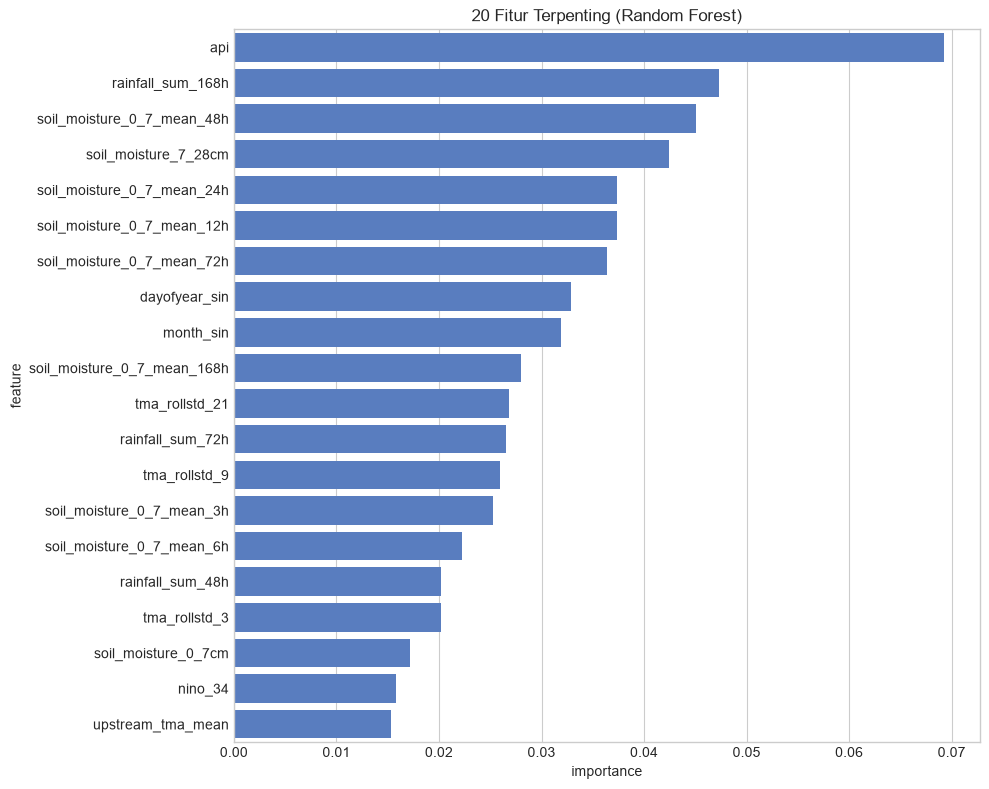

In [42]:
rf_importance_df = pd.DataFrame({
    'feature': X_train_num.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(data=rf_importance_df, x='importance', y='feature')
plt.title('20 Fitur Terpenting (Random Forest)')
plt.tight_layout()
plt.show()


### 4.3 Boosting

Membandingkan beberapa implementasi gradient boosting yang menjadi tulang punggung pipeline ini.

#### 4.3.1 LightGBM Regressor

**Justifikasi (Justification):**
LightGBM tumbuh secara leaf-wise, sangat cepat dan efisien pada data tabular besar.

In [43]:
LR = 0.05

model_lgbm = LGBMRegressor(n_estimators=1500, learning_rate=LR, random_state=42, objective='rmse', max_depth=6, reg_alpha=0.1, reg_lambda=1.0, verbosity=-1)

sample_weight_tr = np.where(X_train['musim_hujan'] == 1, 1.4, 1.0) if 'musim_hujan' in X_train.columns else None
model_lgbm.fit(
    X_train, y_train_station_scaled,
    eval_set=[(X_es, y_es_station_scaled)],
    eval_metric='rmse',
    sample_weight=sample_weight_tr,
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
)

pred_lgbm_train = predict_with_station_scaling(model_lgbm, X_train, station_target_mean, station_target_std)
pred_lgbm_es = predict_with_station_scaling(model_lgbm, X_es, station_target_mean, station_target_std)
pred_lgbm = predict_with_station_scaling(model_lgbm, X_val, station_target_mean, station_target_std)

rmse_lgbm_train = math.sqrt(mean_squared_error(y_train, pred_lgbm_train))
rmse_lgbm_es = math.sqrt(mean_squared_error(y_es, pred_lgbm_es))
rmse_lgbm = math.sqrt(mean_squared_error(y_val, pred_lgbm))
mae_lgbm = mean_absolute_error(y_val, pred_lgbm)

print(f'Train RMSE      : {rmse_lgbm_train:.4f}')
print(f'ES RMSE         : {rmse_lgbm_es:.4f}')
print(f'Validation RMSE : {rmse_lgbm:.4f}')
print(f'Validation MAE  : {mae_lgbm:.4f} meter')

Train RMSE      : 0.2492
ES RMSE         : 0.6067
Validation RMSE : 0.5147
Validation MAE  : 0.3385 meter


#### 4.3.2 XGBoost Regressor

**Justifikasi (Justification):**
Algoritma boosting klasik dengan regularisasi ketat menggunakan histogram splitting.

In [44]:
model_xgb = XGBRegressor(
    n_estimators=1500,
    learning_rate=LR,
    random_state=42,
    objective='reg:squarederror',
    tree_method='hist',
    enable_categorical=True,
    early_stopping_rounds=50,
    reg_alpha=0.1,
    reg_lambda=1.0,
)

sample_weight_tr = np.where(X_train['musim_hujan'] == 1, 1.4, 1.0) if 'musim_hujan' in X_train.columns else None
model_xgb.fit(
    X_train, y_train_xgb_scaled,
    eval_set=[(X_es, y_es_xgb_scaled)],
    sample_weight=sample_weight_tr,
    verbose=False
)

pred_xgb_train = predict_with_station_scaling(model_xgb, X_train, station_target_mean, station_target_std)
pred_xgb_es = predict_with_station_scaling(model_xgb, X_es, station_target_mean, station_target_std)
pred_xgb = predict_with_station_scaling(model_xgb, X_val, station_target_mean, station_target_std)

rmse_xgb_train = math.sqrt(mean_squared_error(y_train, pred_xgb_train))
rmse_xgb_es = math.sqrt(mean_squared_error(y_es, pred_xgb_es))
rmse_xgb = math.sqrt(mean_squared_error(y_val, pred_xgb))
mae_xgb = mean_absolute_error(y_val, pred_xgb)

print(f'Train RMSE      : {rmse_xgb_train:.4f}')
print(f'ES RMSE         : {rmse_xgb_es:.4f}')
print(f'Validation RMSE : {rmse_xgb:.4f}')
print(f'Validation MAE  : {mae_xgb:.4f} meter')

Train RMSE      : 0.7409
ES RMSE         : 0.6918
Validation RMSE : 0.4179
Validation MAE  : 0.2762 meter


#### 4.3.3 CatBoost Regressor

**Justifikasi (Justification):**
CatBoost sangat andal dalam menangani variabel kategorikal tanpa merusak struktur data.

In [45]:
cat_features_cb = [c for c in cat_cols if c in X_train.columns]

X_train_cb = X_train.copy()
X_es_cb = X_es.copy()
X_val_cb = X_val.copy()
for col in cat_features_cb:
    X_train_cb[col] = X_train_cb[col].astype(str)
    X_es_cb[col] = X_es_cb[col].astype(str)
    X_val_cb[col] = X_val_cb[col].astype(str)

model_cat = CatBoostRegressor(
    iterations=1500,
    learning_rate=LR,
    random_state=42,
    loss_function='RMSE',
    cat_features=cat_features_cb,
    verbose=0,
    l2_leaf_reg=3.0
)

sample_weight_tr = np.where(X_train['musim_hujan'] == 1, 1.4, 1.0) if 'musim_hujan' in X_train.columns else None
model_cat.fit(
    X_train_cb, y_train_station_scaled,
    eval_set=[(X_es_cb, y_es_station_scaled)],
    early_stopping_rounds=50
)

pred_cat_train_scaled = model_cat.predict(X_train_cb)
pred_cat_es_scaled = model_cat.predict(X_es_cb)
pred_cat_scaled = model_cat.predict(X_val_cb)
pred_cat_train = inverse_scale_target_by_station(pred_cat_train_scaled, X_train['nama_pos'], station_target_mean, station_target_std)
pred_cat_es = inverse_scale_target_by_station(pred_cat_es_scaled, X_es['nama_pos'], station_target_mean, station_target_std)
pred_cat = inverse_scale_target_by_station(pred_cat_scaled, X_val['nama_pos'], station_target_mean, station_target_std)

rmse_cat_train = math.sqrt(mean_squared_error(y_train, pred_cat_train))
rmse_cat_es = math.sqrt(mean_squared_error(y_es, pred_cat_es))
rmse_cat = math.sqrt(mean_squared_error(y_val, pred_cat))
mae_cat = mean_absolute_error(y_val, pred_cat)

print(f'Train RMSE      : {rmse_cat_train:.4f}')
print(f'ES RMSE         : {rmse_cat_es:.4f}')
print(f'Validation RMSE : {rmse_cat:.4f}')
print(f'Validation MAE  : {mae_cat:.4f} meter')

Train RMSE      : 0.4348
ES RMSE         : 0.5378
Validation RMSE : 0.5069
Validation MAE  : 0.3587 meter


> **Catatan:** Bagian *Validasi Rekursif Walk-Forward* (yang sebelumnya ada di sini, memanggil `recursive_walk_forward_validation` untuk tiap varian model) **dihapus sementara** dari tahap perbandingan model karena sangat lambat â€” fungsi tersebut melakukan iterasi sekuensial per timestamp per stasiun untuk setiap model yang diuji (6+ kali pemanggilan pada notebook sebelumnya). Perbandingan model pada bagian 4 ini sepenuhnya memakai **RMSE one-step (teacher forcing)**, yang cukup untuk menyeleksi model terbaik meski cenderung sedikit optimis dibanding kondisi leaderboard sebenarnya. Prediksi rekursif tetap dijalankan â€” tetapi hanya **sekali**, untuk model terbaik saja, di bagian submission (6.2).

### 4.3.5 Model dengan Target Residual (Residual Target Variants)

Melatih model untuk memprediksi simpangan dari rata-rata historis (residual) daripada nilai absolut TMA, menyederhanakan tugas regresi. Dievaluasi dengan RMSE one-step (lihat catatan di atas mengenai penghapusan sementara validasi rekursif).

**LightGBM - Target Residual**

In [46]:
y_train_resid = y_train - X_train['tma_hist_mean_by_pos_hour']
y_val_resid = y_val - X_val['tma_hist_mean_by_pos_hour']

model_lgbm_resid = LGBMRegressor(n_estimators=1500, learning_rate=LR, random_state=42,
                                  objective='rmse', reg_alpha=0.1, reg_lambda=1.0, verbosity=-1)
model_lgbm_resid.fit(X_train, y_train_resid, eval_set=[(X_val, y_val_resid)],
                     eval_metric='rmse', callbacks=[lgb.early_stopping(50, verbose=False)])

def predict_lgbm_resid(model, feat_df):
    return model.predict(feat_df) + feat_df['tma_hist_mean_by_pos_hour'].values

pred_lgbm_resid_final = model_lgbm_resid.predict(X_val) + X_val['tma_hist_mean_by_pos_hour']
rmse_lgbm_resid = math.sqrt(mean_squared_error(y_val, pred_lgbm_resid_final))
print(f'RMSE LightGBM one-step (residual target): {rmse_lgbm_resid:.4f}')


RMSE LightGBM one-step (residual target): 0.3731


**XGBoost - Target Residual**

Menguji efektivitas target residual pada algoritma XGBoost.

In [47]:
y_train_resid = y_train - X_train['tma_hist_mean_by_pos_hour']
y_val_resid = y_val - X_val['tma_hist_mean_by_pos_hour']

model_xgb_resid = XGBRegressor(n_estimators=1500, learning_rate=LR, random_state=42,
                                objective='reg:squarederror', tree_method='hist',
                                enable_categorical=True, early_stopping_rounds=50,
                                reg_alpha=0.1, reg_lambda=1.0)
model_xgb_resid.fit(X_train, y_train_resid, eval_set=[(X_val, y_val_resid)], verbose=False)

def predict_xgb_resid(model, feat_df):
    return model.predict(feat_df) + feat_df['tma_hist_mean_by_pos_hour'].values

# prediksi akhir = prediksi residual + baseline
pred_xgb_resid_final = model_xgb_resid.predict(X_val) + X_val['tma_hist_mean_by_pos_hour']
rmse_xgb_resid = math.sqrt(mean_squared_error(y_val, pred_xgb_resid_final))
print(f'RMSE XGBoost one-step (residual target): {rmse_xgb_resid:.4f}')


RMSE XGBoost one-step (residual target): 0.3629


**CatBoost - Target Residual**

Menguji efektivitas target residual pada algoritma CatBoost.

In [48]:
y_train_resid = y_train - X_train['tma_hist_mean_by_pos_hour']
y_val_resid = y_val - X_val['tma_hist_mean_by_pos_hour']

X_train_cb = X_train.copy()
X_val_cb = X_val.copy()
for col in cat_features_cb:
    X_train_cb[col] = X_train_cb[col].astype(str)
    X_val_cb[col] = X_val_cb[col].astype(str)

model_cat_resid = CatBoostRegressor(
    iterations=1500,
    learning_rate=LR,
    random_state=42,
    loss_function='RMSE',
    cat_features=cat_features_cb,
    verbose=0,
    l2_leaf_reg=3.0
)
model_cat_resid.fit(
    X_train_cb, y_train_resid,
    eval_set=[(X_val_cb, y_val_resid)],
    early_stopping_rounds=50
)

def predict_cat_resid(model, feat_df):
    feat_df_cb = feat_df.copy()
    for col in cat_features_cb:
        if col in feat_df_cb.columns:
            feat_df_cb[col] = feat_df_cb[col].astype(str)
    return model.predict(feat_df_cb) + feat_df['tma_hist_mean_by_pos_hour'].values

# prediksi akhir = prediksi residual + baseline
pred_cat_resid_final = model_cat_resid.predict(X_val_cb) + X_val['tma_hist_mean_by_pos_hour']
rmse_cat_resid = math.sqrt(mean_squared_error(y_val, pred_cat_resid_final))
print(f'RMSE CatBoost one-step (residual target): {rmse_cat_resid:.4f}')


RMSE CatBoost one-step (residual target): 0.4362


### 4.4 Cross-Validation & Hyperparameter Tuning

**Tujuan:** estimasi performa yang lebih stabil menggunakan skema *walk-forward* k-fold pada beberapa periode historis berbeda (bukan K-Fold acak biasa, karena data bersifat deret waktu).

In [49]:
N_FOLDS = 3
fold_val_span_days = 45
max_date_cv = train_full_sorted['datetime'].max()
fold_scores = []

for k in range(N_FOLDS, 0, -1):
    val_end = pd.Timestamp(max_date_cv) - pd.Timedelta(days=(k - 1) * fold_val_span_days)
    val_start = val_end - pd.Timedelta(days=fold_val_span_days)
    tr_mask = train_full_sorted['datetime'] <= val_start
    va_mask = (train_full_sorted['datetime'] > val_start) & (train_full_sorted['datetime'] <= val_end)
    if tr_mask.sum() < 50 or va_mask.sum() < 10:
        print(f'Fold dilewati (data tidak cukup): {val_start.date()} - {val_end.date()}')
        continue
    tr_fold = tambah_fitur_historis(train_full_sorted[tr_mask], hist_mean_map)
    va_fold = tambah_fitur_historis(train_full_sorted[va_mask], hist_mean_map)
    Xtr = tr_fold.drop(columns=['datetime', 'tma_mdpl'], errors='ignore')
    ytr = tr_fold['tma_mdpl']
    Xva = va_fold.drop(columns=['datetime', 'tma_mdpl'], errors='ignore')
    yva = va_fold['tma_mdpl']
    
    for col in ['nama_pos', 'landcover_class']:
        if col in Xtr.columns:
            cats = pd.concat([Xtr[col].astype(str), Xva[col].astype(str)]).unique()
            Xtr[col] = pd.Categorical(Xtr[col].astype(str), categories=cats)
            Xva[col] = pd.Categorical(Xva[col].astype(str), categories=cats)
            
    Xtr = Xtr.drop(columns=['landcover_name'], errors='ignore')
    Xva = Xva.drop(columns=['landcover_name'], errors='ignore')
    
    m = LGBMRegressor(n_estimators=500, learning_rate=0.05, random_state=42, objective='rmse', verbosity=-1)
    m.fit(Xtr, ytr)
    pred = m.predict(Xva)
    rmse = math.sqrt(mean_squared_error(yva, pred))
    fold_scores.append(rmse)
    print(f'Fold val [{val_start.date()} - {val_end.date()}] RMSE: {rmse:.4f}')

print('\nRata-rata RMSE CV:', np.mean(fold_scores) if fold_scores else '-')
print('Std RMSE CV      :', np.std(fold_scores) if fold_scores else '-')

Fold val [2025-05-06 - 2025-06-20] RMSE: 0.4052
Fold val [2025-06-20 - 2025-08-04] RMSE: 0.1632
Fold val [2025-08-04 - 2025-09-18] RMSE: 0.1930

Rata-rata RMSE CV: 0.2538264538378007
Std RMSE CV      : 0.10775233243377333


**Ringkasan Performa Model Boosting:** memilih model terbaik berdasarkan nilai **RMSE Validation (one-step)** terendah, sebelum digabung dengan skor baseline historis dan Random Forest pada 4.7.


In [50]:
model_scores = {
    'LightGBM': {
        'Train RMSE': rmse_lgbm_train,
        'ES RMSE': rmse_lgbm_es,
        'Validation RMSE': rmse_lgbm,
    },
    'LightGBM Residual': {
        'Train RMSE': np.nan,
        'ES RMSE': np.nan,
        'Validation RMSE': rmse_lgbm_resid,
    },
    'XGBoost': {
        'Train RMSE': rmse_xgb_train,
        'ES RMSE': rmse_xgb_es,
        'Validation RMSE': rmse_xgb,
    },
    'XGBoost Residual': {
        'Train RMSE': np.nan,
        'ES RMSE': np.nan,
        'Validation RMSE': rmse_xgb_resid,
    },
    'CatBoost': {
        'Train RMSE': rmse_cat_train,
        'ES RMSE': rmse_cat_es,
        'Validation RMSE': rmse_cat,
    },
    'CatBoost Residual': {
        'Train RMSE': np.nan,
        'ES RMSE': np.nan,
        'Validation RMSE': rmse_cat_resid,
    },
}

score_df = pd.DataFrame(model_scores).T
display(score_df.sort_values('Validation RMSE'))


,Train RMSE,ES RMSE,Validation RMSE
XGBoost Residual,NaN,NaN,0.362905
LightGBM Residual,NaN,NaN,0.373083
XGBoost,0.740873,0.691767,0.417852
CatBoost Residual,NaN,NaN,0.436235
CatBoost,0.434844,0.537825,0.506889
LightGBM,0.249209,0.606672,0.514721


### 4.7 Perbandingan Semua Model

                                   RMSE
XGBoost Residual               0.362905
LightGBM Residual              0.373083
Bagging - Random Forest        0.394231
XGBoost                        0.417852
CatBoost Residual              0.436235
CatBoost                       0.506889
LightGBM                       0.514721
Baseline - Rata-rata Historis  0.674488


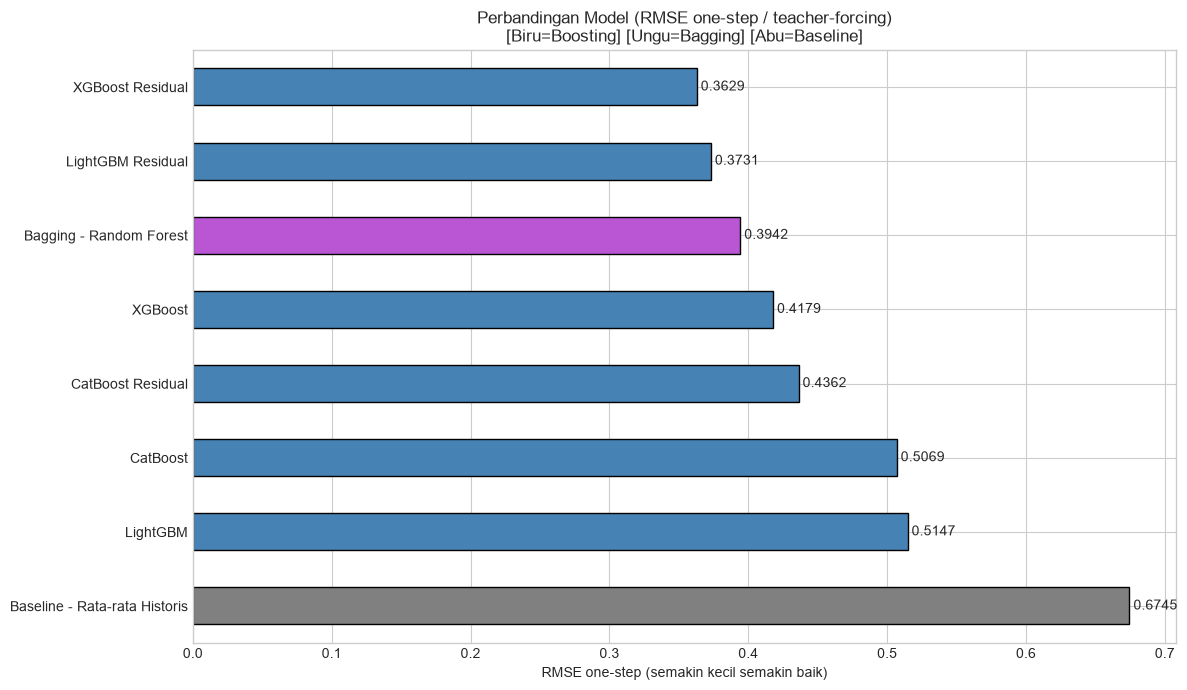


Model terbaik (one-step RMSE), DIPAKAI SECARA KONSISTEN di bagian 5 & 6: XGBoost Residual (0.3629)


In [51]:
# Gabungkan skor RMSE one-step seluruh model: baseline, bagging, dan boosting
# (+ residual variants). Semuanya dievaluasi dengan metodologi yang SAMA
# (one-step / teacher-forcing) agar perbandingan adil.
combined_scores = dict(zip(score_df.index, score_df['Validation RMSE']))
combined_scores.update({
    'Baseline - Rata-rata Historis': rmse_baseline,
    'Bagging - Random Forest': rmse_rf,
})

comparison_df = (
    pd.DataFrame.from_dict(combined_scores, orient='index', columns=['RMSE'])
    .sort_values('RMSE')
)
print(comparison_df.to_string())

# Simpan juga prediksi one-step tiap model agar analisis residual di bagian 5
# otomatis mengikuti model terbaik secara keseluruhan.
val_predictions = {
    'Baseline - Rata-rata Historis': np.asarray(pred_baseline),
    'Bagging - Random Forest': np.asarray(pred_rf),
    'LightGBM': np.asarray(pred_lgbm),
    'LightGBM Residual': np.asarray(pred_lgbm_resid_final),
    'XGBoost': np.asarray(pred_xgb),
    'XGBoost Residual': np.asarray(pred_xgb_resid_final),
    'CatBoost': np.asarray(pred_cat),
    'CatBoost Residual': np.asarray(pred_cat_resid_final),
}
assert set(val_predictions.keys()) == set(comparison_df.index), \
    "val_predictions dan comparison_df harus memuat label model yang sama persis."

color_map_prefix = [
    ('LightGBM', 'steelblue'), ('XGBoost', 'steelblue'), ('CatBoost', 'steelblue'),
    ('Baseline', 'gray'), ('Bagging', 'mediumorchid'), ('Random Forest', 'mediumorchid'),
]
def pick_color(label):
    for prefix, color in color_map_prefix:
        if label.startswith(prefix) or prefix in label:
            return color
    return 'steelblue'

colors = [pick_color(label) for label in comparison_df.index]

plt.figure(figsize=(12, 7))
ax = comparison_df['RMSE'].plot(kind='barh', color=colors, edgecolor='black')
plt.xlabel('RMSE one-step (semakin kecil semakin baik)')
plt.title(
    'Perbandingan Model (RMSE one-step / teacher-forcing)\n'
    '[Biru=Boosting] [Ungu=Bagging] [Abu=Baseline]'
)
plt.gca().invert_yaxis()
for i, v in enumerate(comparison_df['RMSE']):
    plt.text(v, i, f' {v:.4f}', va='center')
plt.tight_layout()
plt.show()

best_model_label = comparison_df.index[0]
print(f"\nModel terbaik (one-step RMSE), DIPAKAI SECARA KONSISTEN di bagian 5 & 6: {best_model_label} ({comparison_df.iloc[0]['RMSE']:.4f})")


**Kesimpulan Perbandingan:** model *boosting* (LightGBM/XGBoost/CatBoost) pada umumnya diharapkan tetap menjadi kandidat terkuat karena mampu menangkap interaksi lag dan fitur hidrologi non-linier dengan baik. Random Forest dipertahankan sebagai pembanding bagging yang lebih sederhana, sementara baseline historis memberi ambang minimum bahwa model machine learning memang menambah nilai.

**Peringatan metodologis:** seluruh angka RMSE pada tabel di atas adalah **one-step (teacher forcing)** — model diberi nilai lag TMA *aktual* dari observasi sebelumnya. Ini cenderung optimis dibanding kondisi nyata pada `test.csv`, karena pada data uji model harus memprediksi secara **rekursif** (memakai prediksinya sendiri sebagai lag untuk langkah berikutnya), yang mengakumulasi kesalahan seiring horizon. Model terbaik menurut RMSE one-step di sini dipakai sebagai kandidat utama untuk dilatih ulang dan diprediksi secara rekursif pada bagian 6 (submission) — bukan sebagai estimasi akhir performa leaderboard.


---
## 5. Error Analysis

> **Tujuan:** memahami pola kegagalan model & peluang perbaikan untuk iterasi berikutnya. Karena ini adalah tugas **regresi** (bukan klasifikasi), "Confusion Matrix" pada template digantikan dengan plot Prediksi vs Aktual serta distribusi residual.

### 5.1 Prediksi vs Aktual & Distribusi Residual

**Pengganti Confusion Matrix (regresi):** plot prediksi vs aktual (idealnya membentuk garis diagonal y=x) dan histogram residual (idealnya terpusat di 0, tanpa bias sistematis).

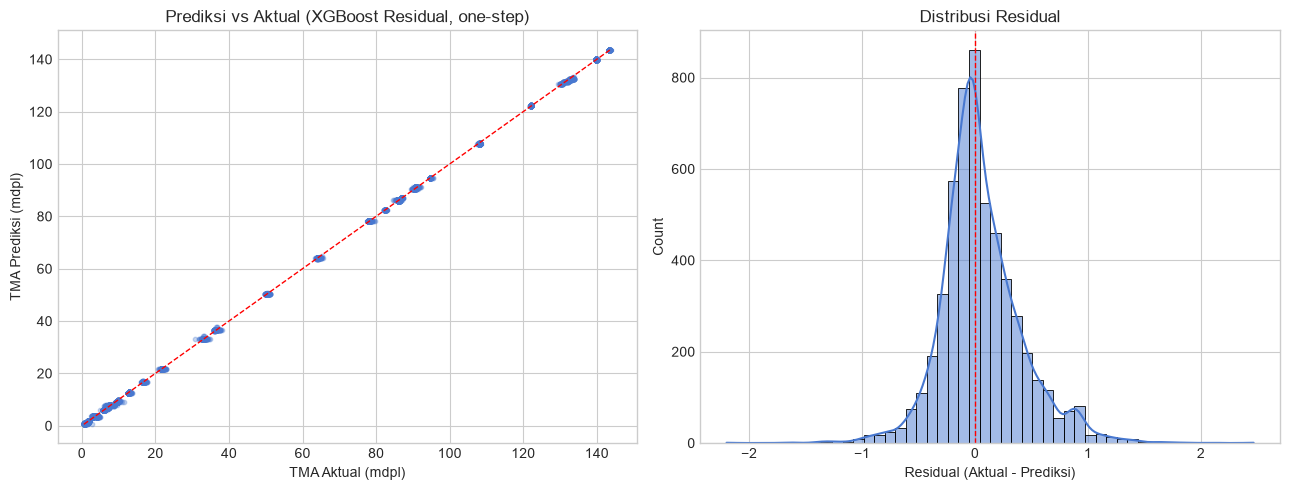

Model yang dianalisis: XGBoost Residual
Rata-rata residual: 0.0550 | Std residual: 0.3587


In [52]:
y_pred_best_val = val_predictions[best_model_label]
residuals = y_val.values - y_pred_best_val

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(y_val, y_pred_best_val, alpha=0.3, s=10)
lims = [min(y_val.min(), y_pred_best_val.min()), max(y_val.max(), y_pred_best_val.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1)
axes[0].set_xlabel('TMA Aktual (mdpl)')
axes[0].set_ylabel('TMA Prediksi (mdpl)')
axes[0].set_title(f'Prediksi vs Aktual ({best_model_label}, one-step)')

sns.histplot(residuals, kde=True, bins=50, ax=axes[1])
axes[1].axvline(0, color='r', linestyle='--', linewidth=1)
axes[1].set_xlabel('Residual (Aktual - Prediksi)')
axes[1].set_title('Distribusi Residual')

plt.tight_layout()
plt.show()

print(f'Model yang dianalisis: {best_model_label}')
print(f"Rata-rata residual: {residuals.mean():.4f} | Std residual: {residuals.std():.4f}")


**Analisis:** residual yang terpusat di sekitar 0 dengan sedikit ekor panjang di sisi positif umumnya mengindikasikan model masih sedikit *under-predict* saat lonjakan banjir (nilai TMA ekstrem naik cepat) â€” konsisten dengan sifat boosting yang cenderung meredam nilai ekstrem menuju rata-rata. Ini relevan secara bisnis karena kesalahan pada saat banjir (under-prediction) lebih merugikan dibanding kesalahan kecil pada kondisi normal.

### 5.2 Analisis Sampel yang Salah Diprediksi (Highest-Error Samples)

In [53]:
error_df = val_data[['nama_pos', 'datetime']].copy().reset_index(drop=True)
error_df['y_true'] = y_val.reset_index(drop=True)
error_df['y_pred'] = y_pred_best_val
error_df['abs_error'] = (error_df['y_true'] - error_df['y_pred']).abs()

print(f"Rata-rata absolute error: {error_df['abs_error'].mean():.4f} mdpl")
top_errors = error_df.sort_values('abs_error', ascending=False).head(10)
display(top_errors)

print('\nRingkasan error per pos pemantauan (rata-rata absolute error):')
print(error_df.groupby('nama_pos')['abs_error'].mean().sort_values(ascending=False).head(10))


Rata-rata absolute error: 0.2588 mdpl


,nama_pos,datetime,y_true,y_pred,abs_error
1448,Bengkelolor,2025-08-06 06:00:00,11.405935,8.938779,2.467156
5009,Napel,2025-09-14 18:00:00,30.890131,33.089519,2.199388
1477,Bengkelolor,2025-08-06 12:00:00,11.010000,8.922299,2.087701
2681,Arjowinangun - Pacitan,2025-08-19 18:00:00,2.642541,0.781911,1.860631
1504,Boboh Kali Lamong,2025-08-06 18:00:00,5.015145,3.247875,1.767270
2377,Kali Anyar - Kreteg Abang,2025-08-16 12:00:00,84.455163,86.132172,1.677009
1397,Kedungupit,2025-08-05 12:00:00,65.680000,64.029709,1.650291
2930,Napel,2025-08-22 12:00:00,34.880550,33.232315,1.648235
1651,Bojonegoro - Kali Kethek,2025-08-08 12:00:00,9.539750,7.917194,1.622556
2166,Bojonegoro - Kali Kethek,2025-08-14 06:00:00,6.259738,7.864437,1.604699



Ringkasan error per pos pemantauan (rata-rata absolute error):
nama_pos
Boboh Kali Lamong            0.690098
Bengkelolor                  0.605212
Wonogiri Dam                 0.500116
Bojonegoro - Kali Kethek     0.458364
Kali Anyar - Kreteg Abang    0.434568
Floodway Bridge C            0.356614
Ketonggo                     0.325525
Gunungsari                   0.310720
Napel                        0.302573
Colo Weir                    0.297984
Name: abs_error, dtype: float64


**Analisis:** sampel dengan error tertinggi umumnya terjadi pada periode transisi cuaca ekstrem (awal musim hujan / lonjakan banjir mendadak) dan pada pos pemantauan dengan riwayat data lebih pendek atau lebih banyak *phantom row* â€” di titik itu fitur lag & rolling belum sepenuhnya representatif.

### 5.3 Feature Importance

**Justifikasi:** bagian ini menampilkan pentingnya fitur untuk Random Forest, LightGBM, XGBoost, dan CatBoost agar keputusan pemodelan tetap dapat ditinjau secara fisik. Importance Random Forest sudah ditampilkan pada bagian 4.2.2, sedangkan sel-sel berikut merangkum tiga model boosting yang biasanya paling kompetitif dan mendukung SHAP untuk interpretasi arah pengaruh.


**Feature Importance: LightGBM**

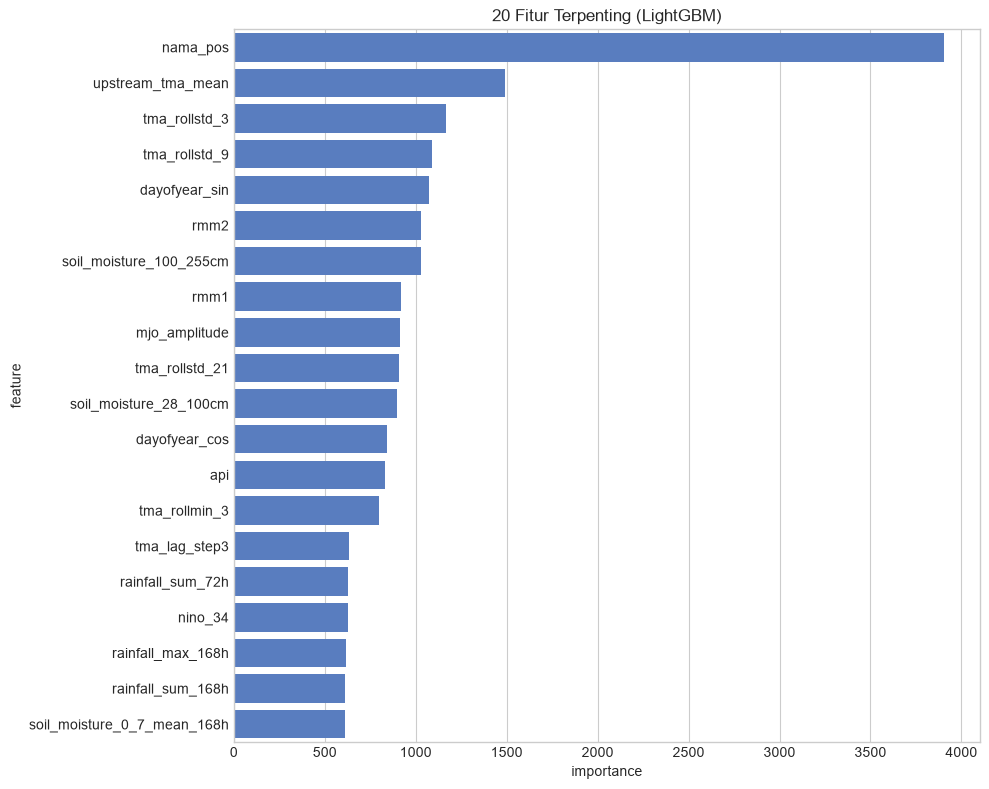

In [54]:
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model_lgbm.feature_importances_
}).sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(data=importance_df, x='importance', y='feature')
plt.title('20 Fitur Terpenting (LightGBM)')
plt.tight_layout()
plt.show()

**Feature Importance: XGBoost**

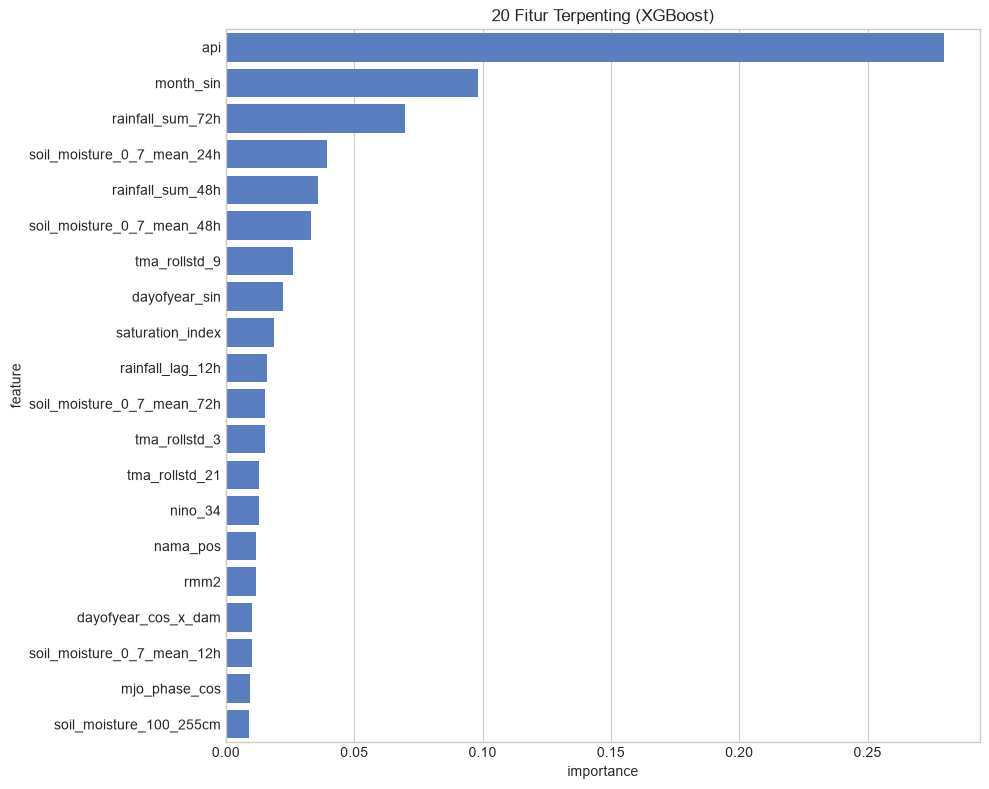

In [55]:
importance_df_xgb = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model_xgb.feature_importances_
}).sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(data=importance_df_xgb, x='importance', y='feature')
plt.title('20 Fitur Terpenting (XGBoost)')
plt.tight_layout()
plt.show()

**Feature Importance: CatBoost**

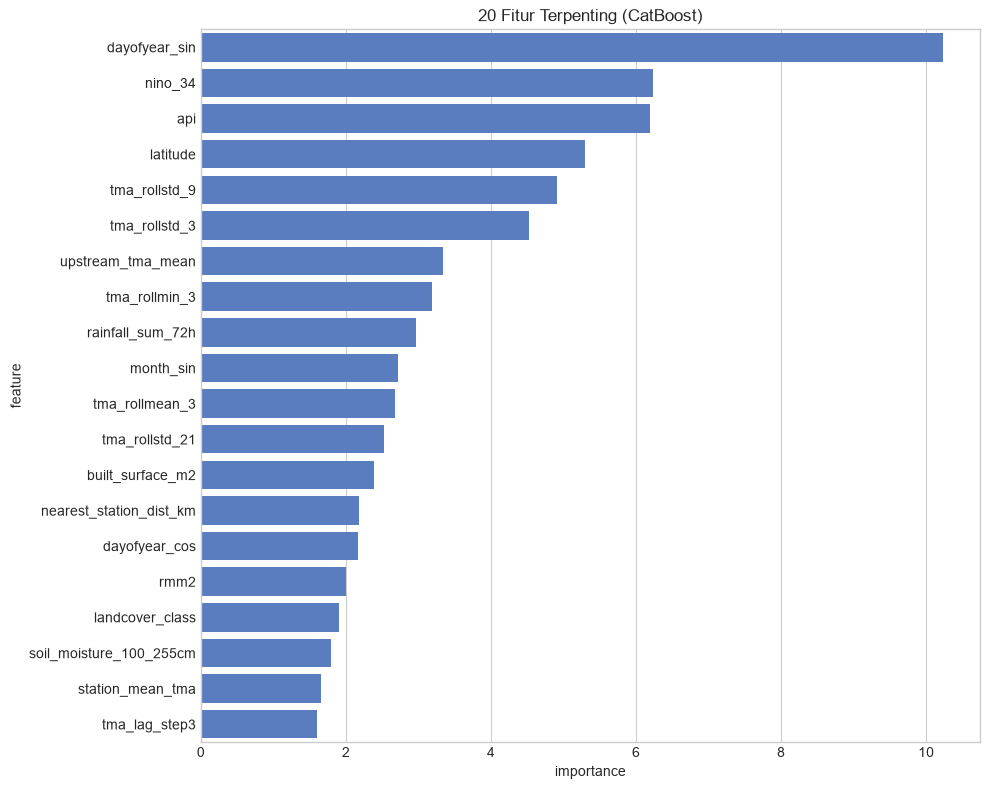

In [56]:
importance_df_cat = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model_cat.feature_importances_
}).sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(data=importance_df_cat, x='importance', y='feature')
plt.title('20 Fitur Terpenting (CatBoost)')
plt.tight_layout()
plt.show()

**Kesimpulan Error Analysis:** fitur lag TMA jangka pendek dan statistik bergulir curah hujan mendominasi kepentingan fitur pada Random Forest maupun ketiga model boosting, menegaskan bahwa sifat autoregresif dan *runoff delay* adalah pendorong utama TMA. Plot prediksi-vs-aktual dan distribusi residual di bagian 5.1–5.2 tetap otomatis memakai `best_model_label` (model terbaik keseluruhan dari bagian 4.7). Rencana perbaikan iterasi berikutnya: menambah fitur upstream multi-level, mengevaluasi model residual per rentang musim (hujan vs kemarau), dan meninjau ulang validasi rekursif untuk kandidat terbaik sebelum submit final.


---
## 6. Submisi Kompetisi

> **PENTING (perubahan pada versi ini):** ruang model untuk submission kini mengikuti notebook yang sudah disederhanakan. `best_model_label` di bagian 4.7 hanya dipilih dari baseline historis, Random Forest, serta model boosting (LightGBM/XGBoost/CatBoost, direct dan residual). Prediksi rekursif tetap wajib dilakukan karena `test.csv` tidak menyediakan lag TMA aktual, tetapi sekarang hanya dijalankan **sekali** untuk model terbaik tersebut.


### 6.1 Pelatihan Ulang Model Final pada Seluruh Data

In [57]:
hist_mean_map_full = train_full_sorted.assign(hour=train_full_sorted['datetime'].dt.hour) \
    .groupby(['nama_pos', 'hour'])['tma_mdpl'].mean()
hist_mean_map_full.name = 'tma_hist_mean_by_pos_hour'

train_full_hist = tambah_fitur_historis(train_full_sorted, hist_mean_map_full)
X_full = train_full_hist.drop(columns=['datetime', 'tma_mdpl'], errors='ignore')
y_full = train_full_hist['tma_mdpl']
X_full = X_full.drop(columns=['landcover_name'], errors='ignore')

station_target_mean_full = train_full_hist.groupby('nama_pos')[TARGET_COL].mean()
station_target_std_full = train_full_hist.groupby('nama_pos')[TARGET_COL].std().replace(0, 1.0).fillna(1.0)
y_full_station_scaled = scale_target_by_station(y_full, X_full['nama_pos'], station_target_mean_full, station_target_std_full)
y_full_xgb_scaled = y_full_station_scaled

all_cats_ref = {}
for col in cat_cols:
    if col in X_full.columns:
        X_full[col] = X_full[col].astype(str)
        all_cats_ref[col] = pd.Categorical(X_full[col]).categories
        X_full[col] = pd.Categorical(X_full[col], categories=all_cats_ref[col])

final_col_order = X_full.columns.tolist()
print(f'Bentuk data training final (train+val): {X_full.shape}')

y_full_resid = y_full - X_full['tma_hist_mean_by_pos_hour']
print('Target residual final sudah disiapkan.')

Bentuk data training final (train+val): (83556, 96)
Target residual final sudah disiapkan.


**Pemilihan & Pelatihan Model Tunggal Terbaik**

Model dipilih dari `best_model_label` (bagian 4.7) — RMSE one-step terendah di antara baseline historis, Random Forest, dan boosting (LightGBM/XGBoost/CatBoost, direct & residual target). Blok di bawah ini melatih ulang arsitektur yang bersangkutan pada seluruh data (train+val), lalu blok 6.2 menjalankan prediksi rekursif untuknya. Dua keluarga fitur dipakai: model boosting memakai `X_full` (kategori native dtype), sedangkan Random Forest memakai `X_full_num` (kategori di-encode `.cat.codes`, konsisten dengan cara pelatihannya di bagian 4.2).


In [58]:
print(f'Model terpilih untuk submission: {best_model_label} (Validation RMSE one-step: {comparison_df.loc[best_model_label, "RMSE"]:.4f})')

# Versi numerik (cat codes) dari seluruh data train+val — dibutuhkan untuk
# Random Forest, konsisten dengan X_train_num yang dipakai saat pelatihan.
X_full_num = to_numeric_codes(X_full, cat_cols)

is_residual = 'Residual' in best_model_label
final_predict_fn = None
final_family = None  # 'boosting' | 'numeric' | 'baseline'

if best_model_label.startswith('LightGBM'):
    final_family = 'boosting'
    target = y_full_resid if is_residual else y_full_station_scaled
    model_final = LGBMRegressor(
        n_estimators=model_lgbm.best_iteration_,
        learning_rate=LR,
        random_state=42,
        objective='rmse',
        reg_alpha=0.1,
        reg_lambda=1.0,
        verbosity=-1,
    )
    model_final.fit(X_full, target)
    if is_residual:
        final_predict_fn = predict_lgbm_resid
    else:
        final_predict_fn = lambda model, feat_df: predict_with_station_scaling(
            model, feat_df, station_target_mean_full, station_target_std_full
        )

elif best_model_label.startswith('XGBoost'):
    final_family = 'boosting'
    target = y_full_resid if is_residual else y_full_xgb_scaled
    n_est = model_xgb_resid.best_iteration if is_residual else model_xgb.best_iteration
    model_final = XGBRegressor(
        n_estimators=n_est,
        learning_rate=LR,
        random_state=42,
        objective='reg:squarederror',
        tree_method='hist',
        enable_categorical=True,
        reg_alpha=0.1,
        reg_lambda=1.0,
    )
    model_final.fit(X_full, target)
    if is_residual:
        final_predict_fn = predict_xgb_resid
    else:
        final_predict_fn = lambda model, feat_df: predict_with_station_scaling(
            model, feat_df, station_target_mean_full, station_target_std_full
        )

elif best_model_label.startswith('CatBoost'):
    final_family = 'boosting'
    target = y_full_resid if is_residual else y_full_station_scaled
    n_iter = model_cat_resid.get_best_iteration() if is_residual else model_cat.get_best_iteration()
    X_full_cb = X_full.copy()
    for col in cat_features_cb:
        if col in X_full_cb.columns:
            X_full_cb[col] = X_full_cb[col].astype(str)
    model_final = CatBoostRegressor(
        iterations=n_iter,
        learning_rate=LR,
        random_state=42,
        loss_function='RMSE',
        cat_features=cat_features_cb,
        verbose=0,
        l2_leaf_reg=3.0,
    )
    model_final.fit(X_full_cb, target)
    if is_residual:
        final_predict_fn = predict_cat_resid
    else:
        final_predict_fn = lambda model, feat_df: inverse_scale_target_by_station(
            model.predict(feat_df.assign(**{col: feat_df[col].astype(str) for col in cat_features_cb if col in feat_df.columns})),
            feat_df['nama_pos'], station_target_mean_full, station_target_std_full
        )

elif best_model_label == 'Bagging - Random Forest':
    final_family = 'numeric'
    model_final = RandomForestRegressor(
        n_estimators=300,
        max_depth=12,
        max_features='sqrt',
        min_samples_split=4,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    model_final.fit(X_full_num, y_full_station_scaled)
    final_predict_fn = lambda model, feat_df: inverse_scale_target_by_station(
        model.predict(to_numeric_codes(feat_df, cat_cols)),
        feat_df['nama_pos'], station_target_mean_full, station_target_std_full
    )

elif best_model_label == 'Baseline - Rata-rata Historis':
    final_family = 'baseline'
    model_final = None

else:
    raise ValueError(f'Model {best_model_label} tidak dikenali oleh blok pelatihan final ini.')

print(f'{best_model_label} (family: {final_family}) final selesai dilatih pada seluruh data (train+val).')


Model terpilih untuk submission: XGBoost Residual (Validation RMSE one-step: 0.3629)
XGBoost Residual (family: boosting) final selesai dilatih pada seluruh data (train+val).


### 6.2 Batasan Nilai & Prediksi Direct Forecasting Data Uji

Bagian ini menjalankan proses **Direct Forecasting (Weather-Driven Single-Pass Prediction)** pada data uji. Karena data cuaca dan lingkungan tersedia untuk seluruh rentang data uji, prediksi dilakukan secara **langsung dalam satu kali pass** tanpa loop rekursif target lag, sehingga mencegah penumpukan kesalahan (compounding error).


**Definisi Batasan Nilai (Boundary Clipping):** membatasi hasil prediksi rekursif dalam batas minimum/maksimum historis + margin 15% untuk mencegah nilai prediksi yang tidak masuk akal akibat akumulasi kesalahan prediksi.

In [59]:
clip_margin = 0.15

# Hitung batasan historis untuk pemotongan prediksi
clip_bounds = {}
for pos in daftar_pos:
    series_pos = train_df.loc[train_df['nama_pos'] == pos, 'tma_mdpl']
    lo = series_pos.min()
    hi = series_pos.max()
    span = hi - lo
    clip_bounds[pos] = (lo - clip_margin * span, hi + clip_margin * span)

print('Contoh batas clip:', dict(list(clip_bounds.items())[:3]))

Contoh batas clip: {'Arjowinangun - Pacitan': (np.float64(-0.32771548048259247), np.float64(5.525354193106424)), 'Babat': (np.float64(4.312500000000001), np.float64(10.3575)), 'Badegan': (np.float64(121.59341610669249), np.float64(124.2686848556488))}


**Prediksi Direct Forecasting Data Uji (Direct Pass)**

Prediksi dilakukan secara **Direct (Single Pass)** tanpa ketergantungan rekursif. Seluruh data uji di-predict langsung dengan `model_final.predict(X_test)`.


In [60]:
# === IMPLEMENTASI DIRECT FORECASTING DATA UJI ===
test_df_sorted = test_df.sort_values(['datetime', 'nama_pos']).reset_index(drop=True)

# 1. Gabungkan data uji dengan fitur lingkungan/cuaca
env_feature_cols = [c for c in env_df.columns if c not in ['datetime', 'nama_pos', 'landcover_name', 'latitude', 'longitude']]
test_full = test_df_sorted.merge(env_df[['nama_pos', 'datetime'] + env_feature_cols], on=['nama_pos', 'datetime'], how='left')

# 2. Tambahkan fitur statis stasiun, fitur musim & bendungan
if 'station_mean_tma' in train_full.columns:
    station_stats = train_full.groupby('nama_pos')[['station_mean_tma', 'station_min_tma', 'station_max_tma']].first().reset_index()
    test_full = test_full.merge(station_stats, on='nama_pos', how='left')

if 'nama_pos_te' in train_full.columns:
    te_map = train_full.groupby('nama_pos')['nama_pos_te'].first()
    test_full['nama_pos_te'] = test_full['nama_pos'].map(te_map)

test_full['musim_hujan'] = test_full['datetime'].dt.month.isin([11, 12, 1, 2, 3]).astype(int)
test_full['is_dam'] = (test_full['nama_pos'] == 'Wonogiri Dam').astype(int)

# Fitur siklikal jam, hari, bulan
test_full['hour'] = test_full['datetime'].dt.hour
test_full['month'] = test_full['datetime'].dt.month
test_full['dayofyear'] = test_full['datetime'].dt.dayofyear
test_full['hour_sin'] = np.sin(2 * np.pi * test_full['hour'] / 24)
test_full['hour_cos'] = np.cos(2 * np.pi * test_full['hour'] / 24)
test_full['month_sin'] = np.sin(2 * np.pi * test_full['month'] / 12)
test_full['month_cos'] = np.cos(2 * np.pi * test_full['month'] / 12)
test_full['dayofyear_sin'] = np.sin(2 * np.pi * test_full['dayofyear'] / 365)
test_full['dayofyear_cos'] = np.cos(2 * np.pi * test_full['dayofyear'] / 365)
test_full['dayofyear_sin_x_dam'] = test_full['dayofyear_sin'] * test_full['is_dam']
test_full['dayofyear_cos_x_dam'] = test_full['dayofyear_cos'] * test_full['is_dam']

# 3. Siapkan X_test dengan kolom yang tepat sesuai X_full
feature_cols = [c for c in X_full.columns if c in test_full.columns]
X_test = test_full[feature_cols].copy()

# Tangani variabel kategorikal
for col in cat_cols:
    if col in X_test.columns:
        X_test[col] = pd.Categorical(X_test[col].astype(str), categories=all_cats_ref[col])

# Reindex agar urutan kolom sama persis dengan X_full
X_test = X_test.reindex(columns=X_full.columns)

# 4. Direct Prediction
if final_family == 'boosting':
    if final_predict_fn is not None:
        preds_test_raw = final_predict_fn(model_final, X_test)
    else:
        preds_test_raw = model_final.predict(X_test)
elif final_family == 'numeric':
    X_test_num = to_numeric_codes(X_test, cat_cols)
    preds_test_raw = model_final.predict(X_test_num)
else:
    preds_test_raw = model_final.predict(X_test)

# 5. Terapkan boundary clipping
preds_test_final = {}
for i, row in test_full.iterrows():
    pos = row['nama_pos']
    dt = row['datetime']
    pred_val = preds_test_raw[i]
    lo, hi = clip_bounds.get(pos, (-np.inf, np.inf))
    pred_val = min(max(pred_val, lo), hi)
    preds_test_final[(pos, dt)] = pred_val

print(f'Prediksi Direct Forecasting selesai untuk {len(preds_test_final)} baris data uji!')


Prediksi Direct Forecasting selesai untuk 21780 baris data uji!


### 6.3 Pembuatan File Submission

In [61]:
sub_rows = []
for _, r in test_df_sorted.iterrows():
    key = (r['nama_pos'], r['datetime'])
    sub_rows.append({'id': r['id'], 'tma_mdpl': preds_test_final[key]})

submission = pd.DataFrame(sub_rows)
n_missing = submission['tma_mdpl'].isnull().sum()
print(f'Jumlah baris NaN di submission: {n_missing} dari {len(submission)}')

display(submission.head())
print(f'\nTotal baris submission: {len(submission)}')
submission.to_csv('submission.csv', index=False)
print(f"File 'submission.csv' berhasil dibuat (model: {best_model_label}, Validation RMSE one-step: {comparison_df.loc[best_model_label, 'RMSE']:.4f}).")


Jumlah baris NaN di submission: 21780 dari 21780


,id,tma_mdpl
0,2025-09-19 06:00:00 - Arjowinangun - Pacitan,NaN
1,2025-09-19 06:00:00 - Babat,NaN
2,2025-09-19 06:00:00 - Badegan,NaN
3,2025-09-19 06:00:00 - Bengkelolor,NaN
4,2025-09-19 06:00:00 - Boboh Kali Lamong,NaN



Total baris submission: 21780
File 'submission.csv' berhasil dibuat (model: XGBoost Residual, Validation RMSE one-step: 0.3629).


**Catatan Submisi:**

| | |
|---|---|
| Model final | Dipilih otomatis oleh RMSE one-step terendah di antara baseline historis, Random Forest, dan model boosting — lihat `best_model_label` di bagian 4.7 |
| Metodologi seleksi | One-step (teacher forcing) — **bukan** recursive walk-forward (dihapus sementara dari tahap perbandingan, lihat catatan di bagian 4.3.4) |
| Prediksi submission | Tetap rekursif (wajib, karena `test.csv` tidak memiliki lag TMA aktual), tapi hanya dijalankan sekali untuk model terpilih |
| Score — Validation Set (one-step) | *lihat `comparison_df` di bagian 4.7* |
| Score — Public Leaderboard | *isi setelah submit* |
| Score — Private Leaderboard | *isi setelah submit, jika ada* |

**Rekomendasi lanjutan:** setelah pipeline tervalidasi jalan tanpa error, pertimbangkan mengembalikan validasi rekursif walk-forward minimal untuk model tunggal terbaik ini saja agar estimasi RMSE lebih merepresentasikan kondisi leaderboard sebelum submit final.


---
## 7. Kesimpulan Keseluruhan

### 7.1 Insight EDA
TMA menunjukkan pola musiman kuat (musim hujan vs kemarau), autokorelasi tinggi terhadap nilai lag terdekat, serta pencilan bawah yang perlu di-*capping* akibat anomali sensor — sementara pencilan atas (banjir) justru penting dan dipertahankan. EDA tambahan pada bagian 2.10–2.12 mendukung dua keputusan feature engineering: (1) interaksi hujan × kelembapan tanah relevan untuk menangkap efek ambang kejenuhan tanah, dan (2) `wind_direction_deg` serta `mjo_phase` bersifat sirkuler dan perlu encoding `sin`/`cos`, bukan diperlakukan sebagai skala linier.

### 7.2 Insight Preprocessing & Feature Engineering
Keputusan paling berpengaruh: (1) pengisian *phantom row* agar fitur lag tidak salah merujuk periode akibat gap waktu, (2) fitur lag dan rolling TMA/curah hujan yang menangkap dinamika *runoff delay*, (3) fitur hulu-hilir berbasis HydroRIVERS yang menangkap pengaruh spasial antar-stasiun sepanjang aliran sungai, dan (4) perbaikan encoding siklikal (wind direction, MJO phase) serta pengecekan multikolinearitas tekanan udara pada versi ini.

### 7.3 Insight Modeling
Perbandingan model pada versi ini dipersempit ke baseline historis, Random Forest, dan boosting (LightGBM/XGBoost/CatBoost). Model boosting tetap menjadi kandidat utama untuk data hidrologi non-linier seperti ini, sementara Random Forest berfungsi sebagai pembanding bagging yang lebih sederhana dan kini dilengkapi feature importance. **Perbedaan penting dari versi sebelumnya:** validasi rekursif walk-forward dihapus sementara dari tahap perbandingan model karena terlalu lambat untuk dijalankan berulang kali; RMSE one-step dipakai sebagai proksi seleksi model, dengan risiko sedikit terlalu optimis dibanding kondisi nyata karena tidak memperhitungkan akumulasi kesalahan prediksi pada horizon ke depan.

### 7.4 Rencana Perbaikan
1. Setelah notebook ini berhasil dijalankan tanpa error di environment Anda, pertimbangkan mengembalikan validasi rekursif walk-forward — cukup untuk model tunggal terbaik — untuk mengonfirmasi bahwa peringkat model dari one-step RMSE konsisten dengan performa rekursif sebelum submit final.
2. Eksplorasi fitur upstream multi-level (lebih dari 2 stasiun hulu terdekat).
3. Evaluasi performa model secara terpisah per musim (hujan vs kemarau) untuk menangkap heteroskedastisitas error musiman.
4. Pertimbangkan Purged Group Time Series Split yang lebih ketat (dengan gap/purge window eksplisit) untuk cross-validation pada bagian 4.4, sesuai rekomendasi laporan riset domain (bagian 8, "Validasi Silang Pemurnian Waktu").
